<a href="https://colab.research.google.com/github/jcanedy/retrainability-index/blob/main/notebooks/paper_stats_tables_and_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Set up

## Install and Import Libraries

In [1]:
!pip install -q skrub kaleido==0.2.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.4/499.4 kB 29.8 MB/s eta 0:00:00


In [2]:
from __future__ import annotations
import seaborn as sns
import matplotlib.figure as mplfig
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager as fm
import polars as pl
import gcsfs
from google.colab import auth
from google.cloud import bigquery
from skrub import TableReport
from sklearn.linear_model import LinearRegression
from scipy.stats import binned_statistic
import geopandas as gpd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.inspection import permutation_importance
import shap
import math


## Initialize BigQuery

In [3]:
auth.authenticate_user()

In [4]:
bq_client = bigquery.Client(project="retraining-index")

def query_bq(query: str) -> pl.DataFrame:

    job = bq_client.query(query)

    df = pl.DataFrame(job.to_dataframe())

    return df

## Add Fonts

In [5]:
!unzip -q Google_Sans_Flex.zip

In [6]:
# Register the downloaded font
font_path = "/content/static/GoogleSansFlex_24pt-Regular.ttf"
fm.fontManager.addfont(font_path)

# Set as default
plt.rcParams["font.family"] = "Google Sans Flex 24pt"

## Create Plotting Helpers

In [7]:
color_palette = {
  "blue": "#174EA6",
  "red": "#A50E0E",
  "orange": "#E37400",
  "green": "#0D652D",
  "medium_blue": "#4285F4",
  "medium_red": "#EA4335",
  "yellow": "#FBBC04",
  "medium_green": "#34A853",
  "light_blue": "#D2E3FC",
  "light_red": "#FAD2CF",
  "light_yellow": "#FEEFC3",
  "light_green": "#CEEAD6",
  "light_grey": "#F1F3F4",
  "grey": "#9AA0A6",
  "black": "#202124"
}


In [8]:
class TitledFigure(mplfig.Figure):
    """
    Figure with title/subtitle aligned to the left edge of the plot (incl. labels).
    """

    def __init__(
        self,
        *args,
        title: str | None = None,
        subtitle: str | None = None,
        align_to_axes: bool = True,
        title_fontsize: int = 20,
        subtitle_fontsize: int = 12,
        subtitle_color: str = color_palette["grey"],
        line_spacing: float = 1.25,
        top_padding_px: int = 10,
        bottom_padding_px: int = 24,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        FigureCanvasAgg(self)

        self._title_raw = title or ""
        self._subtitle_raw = subtitle or ""
        self._align_to_axes = align_to_axes

        self._title_fontsize = title_fontsize
        self._subtitle_fontsize = subtitle_fontsize
        self._subtitle_color = subtitle_color
        self._line_spacing = line_spacing

        self._top_padding_px = top_padding_px
        self._bottom_padding_px = bottom_padding_px

        self._title_artist = None
        self._subtitle_artist = None

    # -------- public API --------
    def finalize_layout(self):
        """
        Call after axes are created.
        """
        self._layout_header()
        self.canvas.draw_idle()
        sns.despine()

    # -------- layout logic --------
    def _layout_header(self):
        # Remove old artists
        for a in (self._title_artist, self._subtitle_artist):
            if a is not None:
                a.remove()

        # Ensure renderer exists
        self.canvas.draw()
        renderer = self.canvas.get_renderer()

        # Determine left alignment from axes tight bbox
        if self._align_to_axes and self.axes:
            # Use the leftmost axes (in case of multiple)
            bboxes = [
                ax.get_tightbbox(renderer) for ax in self.axes
            ]
            left_px = min(b.x0 for b in bboxes)
            right_px = max(b.x1 for b in bboxes)
        else:
            left_px = self.bbox.x0
            right_px = self.bbox.x1

        fig_w_px = self.bbox.width
        fig_h_px = self.bbox.height

        x = left_px / fig_w_px
        max_width_px = right_px - left_px

        # Temporary artists for wrapping & measurement
        self._title_artist = self.text(
            x, 1.0, "",
            ha="left", va="top",
            fontsize=self._title_fontsize,
            fontweight="bold",
            linespacing=self._line_spacing,
        )

        self._subtitle_artist = self.text(
            x, 1.0, "",
            ha="left", va="top",
            fontsize=self._subtitle_fontsize,
            color=self._subtitle_color,
            linespacing=self._line_spacing,
        )

        # Wrap text
        self._title_artist.set_text(
            self._wrap(renderer, self._title_artist, self._title_raw, max_width_px)
        )

        self.canvas.draw()
        title_bbox = self._title_artist.get_window_extent(renderer)

        self._subtitle_artist.set_text(
            self._wrap(renderer, self._subtitle_artist, self._subtitle_raw, max_width_px)
        )

        self.canvas.draw()
        subtitle_bbox = self._subtitle_artist.get_window_extent(renderer)

        # Compute header height
        header_height_px = (
            self._top_padding_px
            + title_bbox.height
            + subtitle_bbox.height
            + self._bottom_padding_px
        )

        header_frac = header_height_px / fig_h_px

        # Position artists
        y_top = 1.0 - self._top_padding_px / fig_h_px
        self._title_artist.set_position((x, y_top))

        gap_px = 6
        y_sub = (
            y_top
            - title_bbox.height / fig_h_px
            - gap_px / fig_h_px
        )
        self._subtitle_artist.set_position((x, y_sub))

        # Push subplots down
        self.subplots_adjust(top=1.0 - header_frac)

    # -------- wrapping --------
    @staticmethod
    def _wrap(renderer, artist, text: str, max_width_px: float) -> str:
        if not text:
            return ""

        words = text.split()
        lines = []
        current = []

        for w in words:
            trial = " ".join(current + [w]) if current else w
            artist.set_text(trial)
            if artist.get_window_extent(renderer).width <= max_width_px:
                current.append(w)
            else:
                if current:
                    lines.append(" ".join(current))
                    current = [w]
                else:
                    lines.append(w)

        if current:
            lines.append(" ".join(current))

        return "\n".join(lines)


## Constants

In [49]:
feature_mapping = {
    "employment_status": {
        1: "Employed",
        2: "Employed, but Notice of Termination",
        3: "Not in labor force",
        0: "Unemployed"
    },
    "received_training": {
        True: "Formal Training",
        False: "No Formal Training"
    },
    "low_income_status": {
        1: "Yes",
        0: "No"
    },
    "race": {
        1: "Hispanic",
        2: "Asian (not Hispanic)",
        3: "Black (not Hispanic)",
        4: "Native Hawaiian or Pacific Islander (not Hispanic)",
        5: "American Indian or Alaska Native (not Hispanic)",
        6: "White (not Hispanic",
        7: "Multiple Race (not Hispanic)"
    },
    "highest_educational_level": {
      1: "Attained secondary school diploma",
      2: "Attained a secondary school equivalency",
      3: "The participant with a disability receives a certificate of attendance/completion as a result of successfully completing an Individualized Education Program (IEP)",
      4: "Completed one of more years of postsecondary education",
      5: "Attained a postsecondary technical or vocational certificate (non-degree)",
      6: "Attained an Associate's degree",
      7: "Attained a Bachelor's degree",
      8: "Attained a degree beyond a Bachelor's degree",
      0: "No Educational Level Completed",
    },
    "training_service_1": {
      1: "On the Job Training (non-WIOA Youth)",
      2: "Skill Upgrading",
      3: "Entrepreneurial Training (non-WIOA Youth)",
      4: "ABE or ESL (contextualized or other) in conjunction with Training",
      5: "Customized Training",
      6: "Occupational Skills Training (nonWIOA Youth)",
      7: "ABE or ESL (contextualized or other) NOT in conjunction with training (funded by Trade Adjustment Assistance only)",
      8: "Prerequisite Training",
      9: "Registered Apprenticeship",
      10: "Youth Occupational Skills Training",
      11: "Other Non-Occupational-Skills Training",
      12: "Job Readiness Training in conjunction with other training",
      0: "No Training Service",
    },
    "sex": {
        1: "Male",
        2: "Female",
        9: "Participant did not self-identify"
    }
}

feature_columns_to_rename = {
    # Program Participation & Structure
    "received_training": "Received Training Indicator",
    "employment_status": "Employment Status at Entry",
    "workforce_board_code": "Local Workforce Board (WDB)",
    "occupational_code_pre": "Pre-Program Occupation",
    "program_year": "Program Year",
    "funding_stream": "Funding Stream",
    "training_service_1": "Training Service Type",

    # Demographics & Individual Characteristics
    "sex": "Sex",
    "race": "Race / Ethnicity",
    "age": "Participant Age",
    "highest_educational_level": "Highest Educational Level",
    "low_income_status": "Low Income Status",
    "state": "State",
    "r_cog_pre": "Routine Cognitive Intensity (Pre-Program)",
    "r_man_pre": "Routine Manual Intensity (Pre-Program)",

    # Regional Economic Indicators (Workforce Board Level)
    'workforce_board_population': "WDB Population",
    'workforce_board_median_age': "WDB Median Age",
    'workforce_board_unemployment_rate': "WDB Unemployment Rate",
    'workforce_board_diversity_index': "WDB Diversity Index",
    'workforce_board_household_debt_to_income_high': "WDB High Household Debt-to-Income Ratio",
    'workforce_board_mean_commuting_time_min': "WDB Mean Commuting Time (Min) ",
    'workforce_board_population_per_sqkm': "WDB Population (per sq km)",
    'workforce_board_metro_status': "WDB Metro Status",
    'workforce_board_median_income_level': "WDB Median Income Level",
    "workforce_board_median_income": "WDB Median Income",
    "workforce_board_rucc": "WDB Metro Status"
}

# 1. Stats

## The number of participant periods in sample.

In [ ]:
query = """
  SELECT
    COUNT(unique_id) AS count,
    COUNT(DISTINCT unique_id) AS distinct_count
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
;
"""

df = query_bq(query)

In [ ]:
print("Number of participant periods in sample:", f'{df["count"].item():,.0f}')

Number of participant periods in sample: 23,766,921


## The number of participant periods we're able to calculate an index for.

In [ ]:
query = """
  SELECT
    COUNT(unique_id) AS count,
    COUNT(DISTINCT unique_id) AS distinct_count
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
  AND index IS NOT NULL
;
"""

df = query_bq(query)

In [ ]:
print("Number of participant periods with an index:", f'{df["count"].item():,.0f}')

Number of participant periods with an index: 11,382,556


## The number of participants who stayed in the same industry.

In [78]:
query = """
  SELECT
    COUNT(unique_id) AS count,
    COUNT(DISTINCT unique_id) AS distinct_count,
    COUNTIF(subsector_code_pre = subsector_code_post) AS same_subsector_count,
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
  AND index_subsector IS NOT NULL
;
"""

df = query_bq(query)

In [81]:
df.select(
    pl.col("same_subsector_count") / pl.col("count"),
)

same_subsector_count
f64
0.454693


## Age and Employment Status (Training Cohort)

In [21]:
query = """
  SELECT
    COUNT(unique_id) AS count,
    COUNT(DISTINCT unique_id) AS distinct_count,
    COUNTIF(employment_status = 0) AS unemployed_count,
    APPROX_QUANTILES(age, 2)[OFFSET(1)] AS age_median,
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
  # AND index_subsector IS NOT NULL
  AND received_training
;
"""

df = query_bq(query)

In [24]:
df.select(
    pl.col("age_median"),
    (pl.col("unemployed_count") / pl.col("count")).alias("unemployed_percent")
)

age_median,unemployed_percent
i64,f64
30,0.68988


## Race and Gender Training Cohort

In [27]:
query = """
  SELECT
    race,
    sex,
    COUNT(unique_id) AS count,
    COUNT(DISTINCT unique_id) AS distinct_count,
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
  # AND index_subsector IS NOT NULL
  AND received_training
  GROUP BY 1, 2
;
"""

df = query_bq(query)

In [30]:
df = df.with_columns(
    pl.col("race").replace_strict(feature_mapping["race"]),
    pl.col("sex").replace_strict(feature_mapping["sex"])
)

count
i64
1080849


In [38]:
df.group_by(
    pl.col("race")
).agg(
    pl.col("count").sum().alias("count")
).with_columns(
    (pl.col("count") / pl.col("count").sum() * 100).alias("percent")
).sort("percent")

race,count,percent
str,i64,f64
"""Native Hawaiian or Pacific Isl…",3496,0.323449
"""American Indian or Alaska Nati…",9996,0.924829
"""Multiple Race (not Hispanic)""",23565,2.180231
"""Asian (not Hispanic)""",29051,2.687795
null,75362,6.972482
"""Hispanic""",221252,20.470204
"""Black (not Hispanic)""",317161,29.343692
"""White (not Hispanic""",400966,37.097319


In [39]:
df.group_by(
    pl.col("sex")
).agg(
    pl.col("count").sum().alias("count")
).with_columns(
    (pl.col("count") / pl.col("count").sum() * 100).alias("percent")
).sort("percent")

sex,count,percent
str,i64,f64
"""Participant did not self-ident…",7993,0.739511
"""Male""",531493,49.173659
"""Female""",541363,50.08683


## Other

In [ ]:
query = """
  SELECT
    *
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
  AND diff_r_cog IS NOT NULL
  AND diff_r_man IS NOT NULL
  AND diff_r_cog_subsector IS NOT NULL
  AND diff_r_man_subsector IS NOT NULL
;
"""

df = query_bq(query)

In [ ]:
df.select(pl.len())

len
u32
148903


In [ ]:
148_903 / 23_766_921 * 100

0.6265136321191963

In [ ]:
diff_rs = ["cog", "man"]
xs = []
ys = []

predictions = []


for diff_r in diff_rs:
  x = df[[f"diff_r_{diff_r}_subsector"]]
  y = df[f"diff_r_{diff_r}"]


  xs.append(x)
  ys.append(y)

  reg = LinearRegression().fit(x, y)

  r2 = reg.score(x, y)
  a, b = reg.coef_[0], reg.intercept_
  x_predict = np.linspace(-3, 3)
  y_predict = a * x_predict + b

  prediction = {
      "x": x[f"diff_r_{diff_r}_subsector"],
      "y": y,
      "r2": r2,
      "a": a,
      "b": b,
      "x_predict": x_predict,
      "y_predict": y_predict
  }

  predictions.append(prediction)

  print(f"y = {a:0.2}x + {b:0.2}\nR^2: {r2:0.2}")

y = 0.25x + 0.043
R^2: 0.013
y = 0.25x + 0.098
R^2: 0.027


In [ ]:
results = []

for diff_r in diff_rs:
  x = df[f"diff_r_{diff_r}_subsector"]
  y = df[f"diff_r_{diff_r}"]

  result = binned_statistic(x, y, statistic='mean', bins=10, range=None)

  x_bin = result.bin_edges[:-1].reshape(-1, 1)
  y_bin = result.statistic
  reg = LinearRegression().fit(x_bin, y_bin)

  r2 = reg.score(x_bin, y_bin)
  a, b = reg.coef_[0], reg.intercept_
  x_bin_predict = np.linspace(-3, 3)
  y_bin_predict = a * x_predict + b

  result = {
      "x": result.bin_edges[:-1],
      "y": result.statistic,
      "r2": r2,
      "a": a,
      "b": b,
      "x_bin_predict": x_bin_predict,
      "y_bin_predict": y_bin_predict
  }

  results.append(result)

  print(f"y = {a:0.2}x + {b:0.2}\nR^2: {r2:0.2}")


y = 0.19x + 0.13
R^2: 0.88
y = 0.25x + 0.23
R^2: 0.96


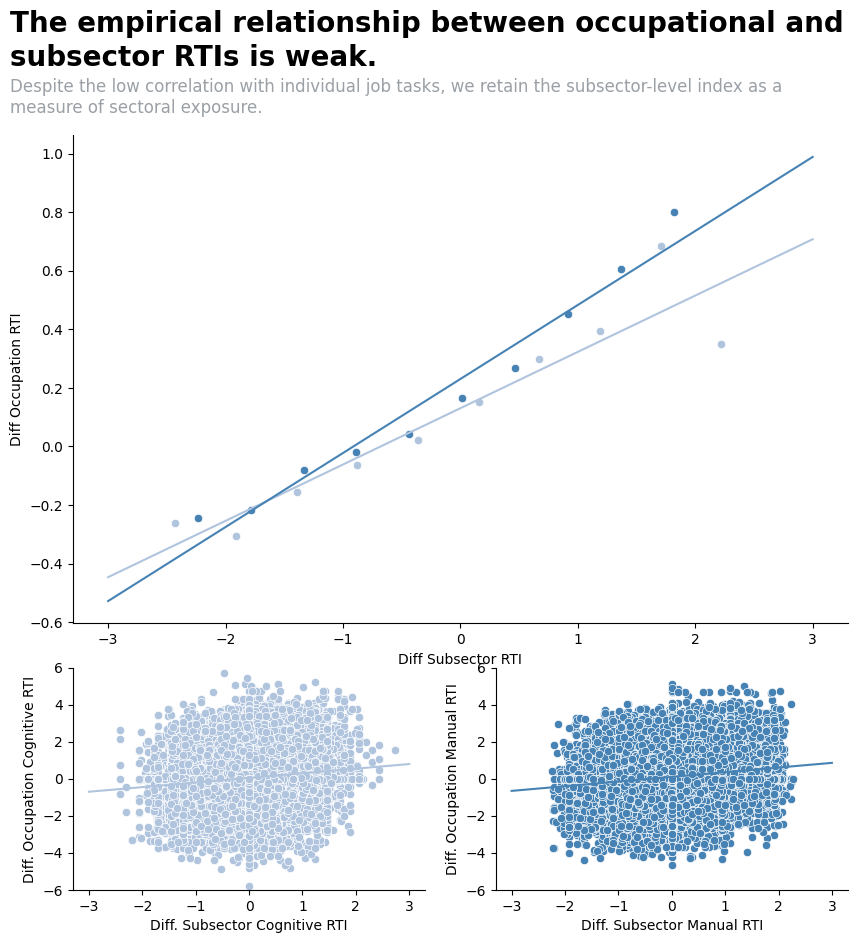

In [ ]:
fig = plt.figure(
    figsize=(10, 10),
    FigureClass=TitledFigure,
    title="The empirical relationship between occupational and subsector RTIs is weak.",
    subtitle="Despite the low correlation with individual job tasks, we retain the subsector-level index as a measure of sectoral exposure. ",
)

gs = GridSpec(3, 2, figure=fig)

colors = ["lightsteelblue", "steelblue"]
labels = ["Cognitive RTI", "Manual RTI"]

ax = fig.add_subplot(gs[0:2, :])

for i, result in enumerate(results):

  sns.scatterplot(
    x=result["x"],
    y=result["y"],
    color=colors[i],
    ax=ax
  )

  sns.lineplot(
      x=result["x_bin_predict"],
      y=result["y_bin_predict"],
      color=colors[i],
      ax=ax
  )

  ax.set_xlabel("Diff Subsector RTI")
  ax.set_ylabel("Diff Occupation RTI")


for i, prediction in enumerate(predictions):

  ax = fig.add_subplot(gs[2, i])

  sns.scatterplot(
    x=prediction["x"],
    y=prediction["y"],
    color=colors[i],
    ax=ax
  )

  sns.lineplot(
      x=prediction["x_predict"],
      y=prediction["y_predict"],
      color=colors[i],
      ax=ax
  )

  ax.set_xlabel(f"Diff. Subsector {labels[i]}")
  ax.set_ylabel(f"Diff. Occupation {labels[i]}")

  ax.set_ylim(-6, 6)

fig.finalize_layout()

plt.show()

# 2. Tables

In [10]:
def create_outcome_table_by_feature(feature: str, query=None) -> str:

  query = query if query else f"""
    SELECT
      {feature},
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
  """

  df = query_bq(query)

  mapping = feature_mapping.get(feature)

  if mapping:
      df = df.with_columns(
        pl.col(feature).replace_strict(mapping, default=pl.col(feature)),
      )

  df = df.with_columns(
    (pl.col("n_positive") / pl.col("n")).alias("incidence"),
    (pl.col("index_sum_positive") / pl.col("n_positive")).alias("intensity"),
    (pl.col("n") / pl.col("unique_id_count")).alias("unique_id_count_not_null"),
    (0.5 * pl.col("diff_r_man_subsector_normalized_mean") + 0.5 * pl.col("diff_r_cog_subsector_normalized_mean")).alias("diff_r_subsector_normalized_mean"),
    ((pl.col("diff_r_man_subsector_normalized_mean") - 0.5) ** 2 + (pl.col("diff_r_cog_subsector_normalized_mean") - 0.5) ** 2).alias("diff_r_subsector_normalized_mean_magnitude")
  )

  feature_to_rename = feature_columns_to_rename[feature]

  columns_to_rename = {
      feature: feature_to_rename,
      "incidence": r"$\text{Incidence}_g$",
      "intensity": r"$\text{Intensity}_g$",
      "wages_mean_diff_normalized_mean": r"$\overline{I^W_n}$",
      "diff_r_cog_subsector_normalized_mean": r"$\overline{I^C_n}$",
      "diff_r_man_subsector_normalized_mean": r"$\overline{I^M_n}$",
      "unique_id_count": "Count",
      "unique_id_count_not_null": r"\% w/ Index",
  }

  df_table = df.rename(columns_to_rename).select(columns_to_rename.values())

  formatters = {
      r"$\overline{I^W_n}$": lambda x: f"{x:,.3f}",
      r"$\overline{I^C_n}$": lambda x: f"{x:,.3f}",
      r"$\overline{I^M_n}$": lambda x: f"{x:,.3f}",
      "Count": lambda x: f"{x:,.0f}",
      r"\% w/ Index": lambda x: rf"{100 * x:,.2f}\%",
      r"$\text{Incidence}_g$": lambda x: f"{x:,.2f}",
      r"$\text{Intensity}_g$": lambda x: f"{x:,.2f}",
  }

  print(
      df_table.to_pandas()
      .to_latex(
          index=False,
          escape=False,
          formatters=formatters,
          caption=feature_to_rename,
          label=f"table:{feature}",
          longtable=True,
          column_format=r">{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr"
        )
      )

  return df

## Received Training

In [ ]:
df = create_outcome_table_by_feature("received_training")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Received Training} \label{table:received_training} \\
\toprule
Received Training & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Received Training} \\
\toprule
Received Training & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
No & 0.49 & 0.57 & 0.497 & 0.500 & 0.499 & 22,686,072 & 48.09\% \\
Yes & 0.64 & 0.60 & 0.592 & 0.511 & 0.512 & 1,080,849 & 43.80\% \\
\end{longtable}



In [ ]:
df

received_training,wages_mean_diff_mean,wages_mean_diff_winsorized_mean,wages_mean_diff_normalized_mean,diff_r_cog_subsector_normalized_mean,diff_r_cog_subsector_winsorized_mean,diff_r_man_subsector_normalized_mean,diff_r_man_subsector_winsorized_mean,index_sum_positive,n_positive,n,unique_id_count,incidence,intensity,unique_id_count_not_null,diff_r_subsector_normalized_mean,diff_r_subsector_normalized_mean_magnitude
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64
"""No""",-1822.289547,-1696.952561,0.49708,0.499696,-0.000747,0.498845,-0.003253,3.0738e6,5381464,10909107,22686072,0.4933,0.571183,0.480872,0.499271,0.000001
"""Yes""",2382.07171,2122.277059,0.59202,0.511442,0.028167,0.511916,0.033546,182831.852862,305326,473449,1080849,0.644897,0.598809,0.438034,0.511679,0.000273


## Employment Status

In [ ]:
df = create_outcome_table_by_feature("employment_status")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Employment Status at Entry} \label{table:employment_status} \\
\toprule
Employment Status at Entry & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Employment Status at Entry} \\
\toprule
Employment Status at Entry & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Unemployed & 0.48 & 0.57 & 0.494 & 0.499 & 0.499 & 19,955,726 & 46.43\% \\
Employed & 0.57 & 0.57 & 0.537 & 0.504 & 0.501 & 3,543,665 & 56.70\% \\
Employed, but Notice of Termination & 0.48 & 0.57 & 0.509 & 0.497 & 0.496 & 210,978 & 47.91\% \\
Not in labor force & 0.52 & 0.58 & 0.527 & 0.513 & 0.505 & 56,552 & 13.41\% \\
\end{longt

## Program Year

In [ ]:
df = create_outcome_table_by_feature("program_year")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Program Year} \label{table:program_year} \\
\toprule
Program Year & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Program Year} \\
\toprule
Program Year & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
2016 & 0.50 & 0.57 & 0.506 & 0.501 & 0.500 & 4,401,541 & 44.85\% \\
2017 & 0.50 & 0.57 & 0.505 & 0.501 & 0.503 & 3,877,284 & 47.51\% \\
2018 & 0.48 & 0.57 & 0.499 & 0.500 & 0.501 & 3,403,637 & 51.87\% \\
2019 & 0.43 & 0.57 & 0.483 & 0.504 & 0.499 & 3,092,935 & 49.92\% \\
2020 & 0.58 & 0.58 & 0.529 & 0.504 & 0.499 & 2,250,278 & 48.33\% \\
2021 & 0.57 & 0.58 & 0.530 & 0.499 & 0.499 & 2,309,217

## Funding Stream

In [ ]:
df = create_outcome_table_by_feature("funding_stream")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Funding Stream} \label{table:funding_stream} \\
\toprule
Funding Stream & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Funding Stream} \\
\toprule
Funding Stream & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Adult & 0.58 & 0.58 & 0.549 & 0.506 & 0.503 & 2,216,881 & 44.50\% \\
Adult, Dislocated worker, or Youth & 0.46 & 0.57 & 0.493 & 0.500 & 0.499 & 458,375 & 52.04\% \\
Dislocated Worker & 0.48 & 0.59 & 0.481 & 0.497 & 0.501 & 1,397,845 & 47.68\% \\
Wagner-Peyser & 0.49 & 0.57 & 0.497 & 0.500 & 0.499 & 19,128,661 & 49.27\% \\
Youth & 0.64 & 0.58 & 0.564 & 0.521 & 0.492 & 565,159 & 11.6

## Training Service Type

In [ ]:
df = create_outcome_table_by_feature("training_service_1")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Training Service Type} \label{table:training_service_1} \\
\toprule
Training Service Type & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Training Service Type} \\
\toprule
Training Service Type & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
NaN & 0.49 & 0.56 & 0.502 & 0.501 & 0.500 & 1,693,001 & 42.18\% \\
No Training Service & 0.49 & 0.57 & 0.497 & 0.500 & 0.499 & 21,024,755 & 48.55\% \\
On the Job Training (non-WIOA Youth) & 0.62 & 0.59 & 0.602 & 0.518 & 0.528 & 100,201 & 53.16\% \\
Skill Upgrading & 0.65 & 0.60 & 0.595 & 0.510 & 0.514 & 133,594 & 53.33\% \\
Entrepreneurial Training (

## Age

In [ ]:
df = create_outcome_table_by_feature("age")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Participant Age} \label{table:age} \\
\toprule
Participant Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Participant Age} \\
\toprule
Participant Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
NaN & 0.54 & 0.57 & 0.503 & 0.500 & 0.503 & 3,952 & 31.20\% \\
13.000000 & 0.45 & 0.58 & 0.495 & 0.498 & 0.502 & 644 & 13.04\% \\
14.000000 & 0.52 & 0.56 & 0.514 & 0.519 & 0.504 & 10,526 & 4.56\% \\
15.000000 & 0.63 & 0.55 & 0.519 & 0.515 & 0.519 & 21,766 & 3.04\% \\
16.000000 & 0.65 & 0.55 & 0.532 & 0.525 & 0.495 & 75,947 & 8.66\% \\
17.000000 & 0.62 & 0.56 & 0.542 & 0.535 & 0.495 & 154,

## Age Group

In [41]:
query = """
SELECT
      CASE
        WHEN age < 5 THEN '0–4'
        WHEN age >= 5  AND age < 10 THEN '5–9'
        WHEN age >= 10 AND age < 15 THEN '10–14'
        WHEN age >= 15 AND age < 20 THEN '15–19'
        WHEN age >= 20 AND age < 25 THEN '20–24'
        WHEN age >= 25 AND age < 30 THEN '25–29'
        WHEN age >= 30 AND age < 35 THEN '30–34'
        WHEN age >= 35 AND age < 40 THEN '35–39'
        WHEN age >= 40 AND age < 45 THEN '40–44'
        WHEN age >= 45 AND age < 50 THEN '45–49'
        WHEN age >= 50 AND age < 55 THEN '50–54'
        WHEN age >= 55 AND age < 60 THEN '55–59'
        WHEN age >= 60 AND age < 65 THEN '60–64'
        WHEN age >= 65 AND age < 70 THEN '65–69'
        WHEN age >= 70 AND age < 75 THEN '70–74'
        WHEN age >= 75 AND age < 80 THEN '75–79'
        WHEN age >= 80 AND age < 85 THEN '80–84'
        WHEN age >= 85 THEN '85+'
        ELSE 'Not available'
      END AS age,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("age", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Participant Age} \label{table:age} \\
\toprule
Participant Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Participant Age} \\
\toprule
Participant Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
10–14 & 0.51 & 0.57 & 0.513 & 0.516 & 0.504 & 11,170 & 5.05\% \\
15–19 & 0.61 & 0.57 & 0.550 & 0.522 & 0.499 & 998,023 & 29.30\% \\
20–24 & 0.57 & 0.57 & 0.536 & 0.504 & 0.499 & 2,606,445 & 47.89\% \\
25–29 & 0.54 & 0.57 & 0.523 & 0.500 & 0.500 & 2,990,297 & 51.69\% \\
30–34 & 0.52 & 0.57 & 0.514 & 0.500 & 0.500 & 2,900,617 & 50.59\% \\
35–39 & 0.51 & 0.57 & 0.507 & 0.499 & 0.500 & 2,657,

## State

In [80]:
df = create_outcome_table_by_feature("state")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{State} \label{table:state} \\
\toprule
State & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{State} \\
\toprule
State & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
AK & 0.49 & 0.58 & 0.516 & 0.501 & 0.506 & 66,861 & 32.62\% \\
AL & 0.55 & 0.57 & 0.528 & 0.503 & 0.499 & 409,400 & 60.28\% \\
AR & 0.50 & 0.56 & 0.496 & 0.499 & 0.495 & 535,924 & 65.04\% \\
AS & NaN & NaN & NaN & NaN & NaN & 386 & 0.00\% \\
AZ & 0.49 & 0.57 & 0.505 & 0.499 & 0.502 & 312,363 & 53.25\% \\
CA & 0.44 & 0.58 & 0.475 & 0.498 & 0.500 & 1,528,270 & 48.67\% \\
CO & 0.50 & 0.58 & 0.508 & 0.501 & 0.498 & 482,724 & 49.2

In [81]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Choropleth(
    locations=df['state'],
    z = df['incidence'],
    locationmode = 'USA-states',
    colorscale = 'RdBu',
    colorbar=dict(
        title='Incidence',
        x=1,      # Position (0-1, where 1 is right edge)
        xpad=0,     # Padding from the edge
        len=1,    # Length of colorbar (0-1)
        y=0.5,      # Vertical position (0.5 is center)
    )
))

fig.update_layout(
    font_family="Google Sans Flex 24pt",
    title_text = '',
    geo_scope='usa',
)

fig.show()
fig.write_image("image-16.png", width=1200, height=800, scale=2)

## State (Received Training)

In [82]:
query = """
    SELECT
      state,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
      AND received_training
    GROUP BY 1
    ORDER BY 1
  ;
"""


df = create_outcome_table_by_feature("state", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{State} \label{table:state} \\
\toprule
State & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{State} \\
\toprule
State & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
AK & 0.71 & 0.61 & 0.625 & 0.506 & 0.531 & 6,200 & 29.02\% \\
AL & 0.65 & 0.59 & 0.598 & 0.518 & 0.514 & 36,100 & 50.51\% \\
AR & 0.67 & 0.60 & 0.604 & 0.519 & 0.507 & 6,642 & 53.82\% \\
AS & NaN & NaN & NaN & NaN & NaN & 11 & 0.00\% \\
AZ & 0.63 & 0.59 & 0.586 & 0.509 & 0.536 & 29,063 & 48.42\% \\
CA & 0.64 & 0.61 & 0.596 & 0.514 & 0.502 & 139,677 & 41.23\% \\
CO & 0.65 & 0.60 & 0.591 & 0.511 & 0.506 & 20,222 & 58.06\% \\
CT

In [83]:
fig = go.Figure(data=go.Choropleth(
    locations=df['state'],
    z = df['incidence'],
    locationmode = 'USA-states',
    colorscale = 'RdBu',
    zmid = 0.5,
    colorbar=dict(
        title='Incidence',
        x=1,      # Position (0-1, where 1 is right edge)
        xpad=0,     # Padding from the edge
        len=1,    # Length of colorbar (0-1)
        y=0.5,      # Vertical position (0.5 is center)
    )
))

fig.update_layout(
    font_family="Google Sans Flex 24pt",
    title_text = '',
    geo_scope='usa',
)

fig.show()
fig.write_image("image-17.png", width=1000, height=800, scale=2)

## Low Income Status

In [ ]:
df = create_outcome_table_by_feature("low_income_status")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Low Income Status} \label{table:low_income_status} \\
\toprule
Low Income Status & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Low Income Status} \\
\toprule
Low Income Status & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
No & 0.49 & 0.57 & 0.494 & 0.500 & 0.500 & 18,501,930 & 49.84\% \\
Yes & 0.54 & 0.58 & 0.529 & 0.503 & 0.499 & 5,264,991 & 41.06\% \\
\end{longtable}



## Race

In [ ]:
df = create_outcome_table_by_feature("race")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Race/Ethnicity} \label{table:race} \\
\toprule
Race/Ethnicity & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Race/Ethnicity} \\
\toprule
Race/Ethnicity & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
NaN & 0.50 & 0.58 & 0.496 & 0.500 & 0.500 & 1,966,997 & 42.87\% \\
Hispanic & 0.51 & 0.57 & 0.515 & 0.501 & 0.498 & 4,405,495 & 46.99\% \\
Asian (not Hispanic) & 0.47 & 0.58 & 0.475 & 0.499 & 0.501 & 565,662 & 42.08\% \\
Black (not Hispanic) & 0.52 & 0.57 & 0.517 & 0.501 & 0.500 & 5,746,133 & 51.68\% \\
Native Hawaiian or Pacific Islander (not Hispanic) & 0.52 & 0.58 & 0.509 & 0.499 & 0.500 

## Highest Educational Level

In [ ]:
df = create_outcome_table_by_feature("highest_educational_level")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Highest Education Level} \label{table:highest_educational_level} \\
\toprule
Highest Education Level & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Highest Education Level} \\
\toprule
Highest Education Level & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
NaN & 0.59 & 0.54 & 0.509 & 0.499 & 0.484 & 6,069 & 7.73\% \\
No Educational Level Completed & 0.50 & 0.56 & 0.509 & 0.502 & 0.496 & 4,011,506 & 45.22\% \\
Attained secondary school diploma & 0.51 & 0.57 & 0.510 & 0.500 & 0.497 & 8,320,409 & 49.28\% \\
Attained a secondary school equivalency & 0.51 & 0.57 & 0.515 & 0.501 & 0.497 & 1,91

## Sex

In [ ]:
df = create_outcome_table_by_feature("sex")

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{Sex} \label{table:sex} \\
\toprule
Sex & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{Sex} \\
\toprule
Sex & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Male & 0.50 & 0.57 & 0.501 & 0.501 & 0.499 & 12,206,949 & 48.59\% \\
Female & 0.50 & 0.57 & 0.501 & 0.499 & 0.499 & 11,232,806 & 47.34\% \\
Participant did not self-identify & 0.52 & 0.57 & 0.505 & 0.500 & 0.499 & 327,166 & 40.82\% \\
\end{longtable}



## WDB Unemployment Rate

In [37]:
query = """
SELECT
      CASE
        WHEN workforce_board_unemployment_rate IS NULL THEN 'Not available'
        WHEN workforce_board_unemployment_rate < 1 THEN '<1%'
        WHEN workforce_board_unemployment_rate >= 1
            AND workforce_board_unemployment_rate < 2 THEN '1–2%'
        WHEN workforce_board_unemployment_rate >= 2
            AND workforce_board_unemployment_rate < 3 THEN '2–3%'
        WHEN workforce_board_unemployment_rate >= 3
            AND workforce_board_unemployment_rate < 4 THEN '3–4%'
        WHEN workforce_board_unemployment_rate >= 4
            AND workforce_board_unemployment_rate < 5 THEN '4–5%'
        WHEN workforce_board_unemployment_rate >= 5
            AND workforce_board_unemployment_rate < 6 THEN '5–6%'
        WHEN workforce_board_unemployment_rate >= 6
            AND workforce_board_unemployment_rate < 7 THEN '6–7%'
        WHEN workforce_board_unemployment_rate >= 7
            AND workforce_board_unemployment_rate < 8 THEN '7–8%'
        WHEN workforce_board_unemployment_rate >= 8
            AND workforce_board_unemployment_rate < 9 THEN '8–9%'
        WHEN workforce_board_unemployment_rate >= 9
            AND workforce_board_unemployment_rate < 10 THEN '9–10%'
        WHEN workforce_board_unemployment_rate >= 10 THEN '10%+'
      END AS workforce_board_unemployment_rate,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_unemployment_rate", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Unemployment Rate} \label{table:workforce_board_unemployment_rate} \\
\toprule
WDB Unemployment Rate & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Unemployment Rate} \\
\toprule
WDB Unemployment Rate & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
10%+ & 0.51 & 0.58 & 0.515 & 0.505 & 0.500 & 405,211 & 43.94\% \\
1–2% & 0.44 & 0.59 & 0.465 & 0.497 & 0.499 & 10,245 & 60.80\% \\
2–3% & 0.49 & 0.58 & 0.492 & 0.499 & 0.500 & 1,189,976 & 50.21\% \\
3–4% & 0.50 & 0.57 & 0.497 & 0.498 & 0.500 & 5,583,296 & 51.07\% \\
4–5% & 0.51 & 0.57 & 0.507 & 0.501 & 0.500 & 4,656,720 & 45.82\% \\
5–

## WDB High Household Debt-to-Income Ratio

In [39]:
query = """
SELECT
      CASE
        WHEN workforce_board_household_debt_to_income_high < 1 THEN '<1'
        WHEN workforce_board_household_debt_to_income_high >= 1
            AND workforce_board_household_debt_to_income_high < 2 THEN '1–2'
        WHEN workforce_board_household_debt_to_income_high >= 2
            AND workforce_board_household_debt_to_income_high < 3 THEN '2–3'
        WHEN workforce_board_household_debt_to_income_high >= 3
            AND workforce_board_household_debt_to_income_high < 4 THEN '3–4'
        WHEN workforce_board_household_debt_to_income_high >= 4 THEN '4+'
        ELSE 'Not available'
      END AS workforce_board_household_debt_to_income_high,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_household_debt_to_income_high", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB High Household Debt-to-Income Ratio} \label{table:workforce_board_household_debt_to_income_high} \\
\toprule
WDB High Household Debt-to-Income Ratio & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB High Household Debt-to-Income Ratio} \\
\toprule
WDB High Household Debt-to-Income Ratio & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
1–2 & 0.51 & 0.57 & 0.506 & 0.500 & 0.500 & 10,659,074 & 48.77\% \\
2–3 & 0.51 & 0.57 & 0.505 & 0.501 & 0.499 & 5,938,243 & 47.94\% \\
3–4 & 0.45 & 0.58 & 0.481 & 0.499 & 0.502 & 475,613 & 38.70\% \\
<1 & 0.51 & 0.58 & 0.508 & 0.501 & 0.502 & 698,921 & 

## WDB Median Age

In [40]:
query = """
SELECT
      CASE
        WHEN workforce_board_median_age < 5 THEN '0–4'
        WHEN workforce_board_median_age >= 5  AND workforce_board_median_age < 10 THEN '5–9'
        WHEN workforce_board_median_age >= 10 AND workforce_board_median_age < 15 THEN '10–14'
        WHEN workforce_board_median_age >= 15 AND workforce_board_median_age < 20 THEN '15–19'
        WHEN workforce_board_median_age >= 20 AND workforce_board_median_age < 25 THEN '20–24'
        WHEN workforce_board_median_age >= 25 AND workforce_board_median_age < 30 THEN '25–29'
        WHEN workforce_board_median_age >= 30 AND workforce_board_median_age < 35 THEN '30–34'
        WHEN workforce_board_median_age >= 35 AND workforce_board_median_age < 40 THEN '35–39'
        WHEN workforce_board_median_age >= 40 AND workforce_board_median_age < 45 THEN '40–44'
        WHEN workforce_board_median_age >= 45 AND workforce_board_median_age < 50 THEN '45–49'
        WHEN workforce_board_median_age >= 50 AND workforce_board_median_age < 55 THEN '50–54'
        WHEN workforce_board_median_age >= 55 AND workforce_board_median_age < 60 THEN '55–59'
        WHEN workforce_board_median_age >= 60 AND workforce_board_median_age < 65 THEN '60–64'
        WHEN workforce_board_median_age >= 65 AND workforce_board_median_age < 70 THEN '65–69'
        WHEN workforce_board_median_age >= 70 AND workforce_board_median_age < 75 THEN '70–74'
        WHEN workforce_board_median_age >= 75 AND workforce_board_median_age < 80 THEN '75–79'
        WHEN workforce_board_median_age >= 80 AND workforce_board_median_age < 85 THEN '80–84'
        WHEN workforce_board_median_age >= 85 THEN '85+'
        ELSE 'Not available'
      END AS workforce_board_median_age,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_median_age", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Median Age} \label{table:workforce_board_median_age} \\
\toprule
WDB Median Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Median Age} \\
\toprule
WDB Median Age & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
25–29 & 0.54 & 0.58 & 0.525 & 0.501 & 0.506 & 17,754 & 45.46\% \\
30–34 & 0.49 & 0.57 & 0.505 & 0.501 & 0.502 & 1,497,407 & 50.06\% \\
35–39 & 0.51 & 0.58 & 0.504 & 0.500 & 0.501 & 8,442,660 & 46.95\% \\
40–44 & 0.51 & 0.57 & 0.505 & 0.500 & 0.498 & 6,748,678 & 49.10\% \\
45–49 & 0.51 & 0.57 & 0.513 & 0.502 & 0.499 & 1,099,791 & 45.04\% \\
50–54 & 0.49 & 0.57 & 0.507 & 

## WDB Population (per sq km)

In [30]:
query = """
SELECT
      CASE
        WHEN workforce_board_population_per_sqkm < 10 THEN '<10'
        WHEN workforce_board_population_per_sqkm >= 10
            AND workforce_board_population_per_sqkm < 50 THEN '10–50'
        WHEN workforce_board_population_per_sqkm >= 50
            AND workforce_board_population_per_sqkm < 200 THEN '50–200'
        WHEN workforce_board_population_per_sqkm >= 200
            AND workforce_board_population_per_sqkm < 1000 THEN '200–1000'
        WHEN workforce_board_population_per_sqkm >= 1000
            AND workforce_board_population_per_sqkm < 4000 THEN '1000–4000'
        WHEN workforce_board_population_per_sqkm >= 4000 THEN '4000+'
        ELSE 'Unknown'
      END AS workforce_board_population_per_sqkm,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_population_per_sqkm", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Population (per sq km)} \label{table:workforce_board_population_per_sqkm} \\
\toprule
WDB Population (per sq km) & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Population (per sq km)} \\
\toprule
WDB Population (per sq km) & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
1000–4000 & 0.48 & 0.58 & 0.495 & 0.501 & 0.504 & 558,499 & 46.68\% \\
10–50 & 0.53 & 0.57 & 0.516 & 0.501 & 0.498 & 5,403,196 & 50.95\% \\
200–1000 & 0.48 & 0.58 & 0.494 & 0.501 & 0.504 & 4,590,913 & 46.74\% \\
4000+ & 0.49 & 0.59 & 0.494 & 0.501 & 0.500 & 815,790 & 36.71\% \\
50–200 & 0.51 & 0.57 & 0.506 & 0.500

## WDB Diversity Index

In [31]:
query = """
SELECT
      CASE
        WHEN workforce_board_diversity_index < 25 THEN '<25'
        WHEN workforce_board_diversity_index >= 25
            AND workforce_board_diversity_index < 50 THEN '25–50'
        WHEN workforce_board_diversity_index >= 50
            AND workforce_board_diversity_index < 75 THEN '50–75'
        WHEN workforce_board_diversity_index >= 75
            AND workforce_board_diversity_index < 100 THEN '75–10'
        WHEN workforce_board_diversity_index >= 100 THEN '100+'
        ELSE 'Unknown'
      END AS workforce_board_diversity_index,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_diversity_index", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Diversity Index} \label{table:workforce_board_diversity_index} \\
\toprule
WDB Diversity Index & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Diversity Index} \\
\toprule
WDB Diversity Index & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
100+ & 0.54 & 0.57 & 0.518 & 0.501 & 0.497 & 6,315,201 & 48.88\% \\
25–50 & 0.48 & 0.58 & 0.496 & 0.498 & 0.503 & 1,172,258 & 47.37\% \\
50–75 & 0.47 & 0.58 & 0.491 & 0.500 & 0.503 & 4,678,679 & 46.97\% \\
75–10 & 0.50 & 0.57 & 0.505 & 0.500 & 0.499 & 5,632,934 & 48.50\% \\
Unknown & 0.48 & 0.57 & 0.489 & 0.499 & 0.498 & 5,967,849 & 47.11\% \\
\

## WDB Population

In [32]:
query = """
SELECT
      CASE
        WHEN workforce_board_population < 100000 THEN '<100K'
        WHEN workforce_board_population >= 100000
            AND workforce_board_population < 1000000 THEN '100K–1M'
        WHEN workforce_board_population >= 1000000 THEN '+1M'
        ELSE 'Unknown'
      END AS workforce_board_population,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_population", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Population} \label{table:workforce_board_population} \\
\toprule
WDB Population & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Population} \\
\toprule
WDB Population & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
+1M & 0.48 & 0.58 & 0.492 & 0.500 & 0.503 & 3,421,138 & 44.57\% \\
100K–1M & 0.51 & 0.57 & 0.504 & 0.501 & 0.501 & 8,574,230 & 47.62\% \\
<100K & 0.52 & 0.57 & 0.513 & 0.501 & 0.498 & 6,142,960 & 50.22\% \\
Unknown & 0.48 & 0.57 & 0.488 & 0.499 & 0.498 & 5,628,593 & 47.79\% \\
\end{longtable}



## WDB Mean Commuting Time (Min)

In [43]:
query = """
SELECT
      CASE
        WHEN workforce_board_mean_commuting_time_min < 15 THEN '<15'
        WHEN workforce_board_mean_commuting_time_min >= 15
            AND workforce_board_mean_commuting_time_min < 30 THEN '15-30'
        WHEN workforce_board_mean_commuting_time_min >= 30
            AND workforce_board_mean_commuting_time_min < 45 THEN '30-45'
        WHEN workforce_board_mean_commuting_time_min >= 45
            AND workforce_board_mean_commuting_time_min < 60 THEN '45-60'
        WHEN workforce_board_mean_commuting_time_min >= 60 THEN '60+'
        ELSE 'Unknown'
      END AS workforce_board_mean_commuting_time_min,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_mean_commuting_time_min", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Mean Commuting Time (Min) } \label{table:workforce_board_mean_commuting_time_min} \\
\toprule
WDB Mean Commuting Time (Min)  & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Mean Commuting Time (Min) } \\
\toprule
WDB Mean Commuting Time (Min)  & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
15-30 & 0.51 & 0.57 & 0.508 & 0.501 & 0.499 & 15,328,256 & 48.76\% \\
30-45 & 0.46 & 0.58 & 0.486 & 0.500 & 0.503 & 2,566,977 & 42.94\% \\
<15 & 0.51 & 0.58 & 0.521 & 0.501 & 0.504 & 23,070 & 17.99\% \\
Unknown & 0.48 & 0.57 & 0.489 & 0.499 & 0.498 & 5,848,618 & 47.90\% \\
\end{longtable}



## WDB Median Income Level

In [47]:
query = """
SELECT
      CASE
        WHEN workforce_board_median_income < 5000 THEN '<$5K'
        WHEN workforce_board_median_income >= 5000
            AND workforce_board_median_income < 10000 THEN '$5–10K'
        WHEN workforce_board_median_income >= 10000
            AND workforce_board_median_income < 15000 THEN '$10–15K'
        WHEN workforce_board_median_income >= 15000
            AND workforce_board_median_income < 20000 THEN '$15–20K'
        WHEN workforce_board_median_income >= 20000
            AND workforce_board_median_income < 25000 THEN '$20–25K'
        WHEN workforce_board_median_income >= 25000
            AND workforce_board_median_income < 30000 THEN '$25–30K'
        WHEN workforce_board_median_income >= 30000
            AND workforce_board_median_income < 35000 THEN '$30–35K'
        WHEN workforce_board_median_income >= 35000
            AND workforce_board_median_income < 40000 THEN '$35–40K'
        WHEN workforce_board_median_income >= 40000
            AND workforce_board_median_income < 45000 THEN '$40–45K'
        WHEN workforce_board_median_income >= 45000
            AND workforce_board_median_income < 50000 THEN '$45–50K'
        WHEN workforce_board_median_income >= 50000
            AND workforce_board_median_income < 60000 THEN '$50–60K'
        WHEN workforce_board_median_income >= 60000
            AND workforce_board_median_income < 75000 THEN '$60–75K'
        WHEN workforce_board_median_income >= 75000 THEN '$75K+'
        ELSE 'Not available'
      END AS workforce_board_median_income,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_median_income", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Median Income} \label{table:workforce_board_median_income} \\
\toprule
WDB Median Income & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Median Income} \\
\toprule
WDB Median Income & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
$10–15K & 0.30 & 0.57 & 0.507 & 0.649 & 0.581 & 86,409 & 5.37\% \\
$15–20K & 0.52 & 0.57 & 0.521 & 0.507 & 0.502 & 418,306 & 47.80\% \\
$20–25K & 0.52 & 0.57 & 0.517 & 0.502 & 0.499 & 2,932,805 & 50.82\% \\
$25–30K & 0.52 & 0.57 & 0.513 & 0.501 & 0.498 & 5,490,576 & 48.60\% \\
$30–35K & 0.51 & 0.57 & 0.505 & 0.501 & 0.500 & 4,691,710 & 46.40\% \\
$35–40K 

## WDB Metro Status

In [52]:
query = """
SELECT
      CASE

        -- Metro counties
        WHEN workforce_board_rucc = 1 THEN 'Metro: 1M+'
        WHEN workforce_board_rucc = 2 THEN 'Metro: 250K–1M'
        WHEN workforce_board_rucc = 3 THEN 'Metro: <250K'

        -- Nonmetro counties
        WHEN workforce_board_rucc = 4 THEN 'Nonmetro: 20K+ adj. metro'
        WHEN workforce_board_rucc = 5 THEN 'Nonmetro: 20K+ not adj. metro'
        WHEN workforce_board_rucc = 6 THEN 'Nonmetro: 5K–20K adj. metro'
        WHEN workforce_board_rucc = 7 THEN 'Nonmetro: 5K–20K not adj. metro'
        WHEN workforce_board_rucc = 8 THEN 'Nonmetro: <5K adj. metro'
        WHEN workforce_board_rucc = 9 THEN 'Nonmetro: <5K not adj. metro'

        ELSE 'Not available'
      END AS workforce_board_rucc,
      AVG(wages_mean_diff) AS wages_mean_diff_mean,
      AVG(wages_mean_diff_winsorized) AS wages_mean_diff_winsorized_mean,
      AVG(wages_mean_diff_normalized) AS wages_mean_diff_normalized_mean,
      AVG(diff_r_cog_subsector) AS diff_r_cog_subsector_mean,
      AVG(diff_r_cog_subsector_normalized) AS diff_r_cog_subsector_normalized_mean,
      AVG(diff_r_cog_subsector_winsorized) AS diff_r_cog_subsector_winsorized_mean,
      AVG(diff_r_man_subsector) AS diff_r_man_subsector_mean,
      AVG(diff_r_man_subsector_normalized) AS diff_r_man_subsector_normalized_mean,
      AVG(diff_r_man_subsector_winsorized) AS diff_r_man_subsector_winsorized_mean,
      SUM(CASE WHEN index_subsector > 0.5 THEN index_subsector ELSE 0 END) AS index_sum_positive,
      COUNTIF(index_subsector > 0.5) AS n_positive,
      COUNTIF(index_subsector IS NOT NULL) AS n,
      COUNT(unique_id) AS unique_id_count,
    FROM `retraining-index.fact.retrainability_index`
    WHERE program_year < 2024
    GROUP BY 1
    ORDER BY 1
  ;
"""

df = create_outcome_table_by_feature("workforce_board_rucc", query)

\begin{longtable}{>{\raggedright\arraybackslash}p{0.15\textwidth}rrrrrrr}
\caption{WDB Metro Status} \label{table:workforce_board_rucc} \\
\toprule
WDB Metro Status & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endfirsthead
\caption[]{WDB Metro Status} \\
\toprule
WDB Metro Status & $\text{Incidence}_g$ & $\text{Intensity}_g$ & $\overline{I^W_n}$ & $\overline{I^C_n}$ & $\overline{I^M_n}$ & Count & \% w/ Index \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Metro: 1M+ & 0.48 & 0.58 & 0.491 & 0.500 & 0.503 & 5,596,833 & 46.45\% \\
Metro: 250K–1M & 0.49 & 0.57 & 0.503 & 0.501 & 0.500 & 1,760,940 & 47.92\% \\
Metro: <250K & 0.50 & 0.57 & 0.507 & 0.501 & 0.497 & 314,979 & 49.14\% \\
Nonmetro: 20K+ adj. metro & 0.52 & 0.57 & 0.516 & 0.500 & 0.502 & 387,741 & 38.53\% \\
Nonmetro: 20K+ not adj. metro & 0.50 & 0.57 & 0.512 & 0.5

# 3. Figures

## Participants by Program Year

In [100]:
query = """
  SELECT
    program_year,
    funding_stream,
    received_training,
    COUNT(unique_id) AS participants,
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  GROUP BY program_year, funding_stream, received_training
  ORDER BY program_year, participants
  ;
"""

df = query_bq(query)

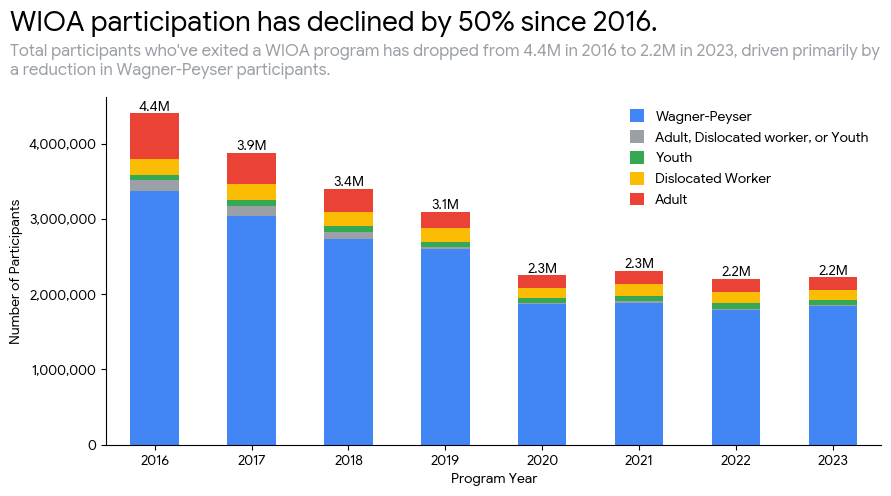

In [101]:
df_pivot = df.pivot(on="funding_stream", values="participants", index="program_year", aggregate_function="sum").to_pandas()

fig = plt.figure(
    figsize=(10, 5),
    FigureClass=TitledFigure,
    title="WIOA participation has declined by 50% since 2016.",
    subtitle="Total participants who've exited a WIOA program has dropped from 4.4M in 2016 to 2.2M in 2023, driven primarily by a reduction in Wagner-Peyser participants.",
)

colormap = {
    "Wagner-Peyser": color_palette["medium_blue"],
    "Adult": color_palette["medium_red"],
    "Dislocated Worker": color_palette["yellow"],
    "Adult, Dislocated worker, or Youth": color_palette["grey"],
    "Youth": color_palette["medium_green"]
}

colors = [colormap[col] for col in df_pivot.columns if col != "program_year"]

ax = fig.add_subplot(111)
df_pivot.plot(x='program_year', kind='bar', stacked=True, color=colors, ax=ax)
labels = [f'{(v.get_y() + v.get_height())/1e6:.1f}M' for v in ax.containers[-1]]
ax.bar_label(ax.containers[-1], labels=labels, fontsize=10)

ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel("Program Year")
ax.set_ylabel("Number of Participants")

ax.legend(
    frameon=False,
    handlelength=1,
    handleheight=1
)


fig.finalize_layout()




In [102]:
df_pivot = df.pivot(on="received_training", values="participants", index="program_year", aggregate_function="sum")

columns_to_sum = [c for c in df_pivot.columns if c != "program_year"]

df_pivot = df_pivot.with_columns(
    (pl.col(columns_to_sum) / pl.sum_horizontal(columns_to_sum)) * 100
).to_pandas()

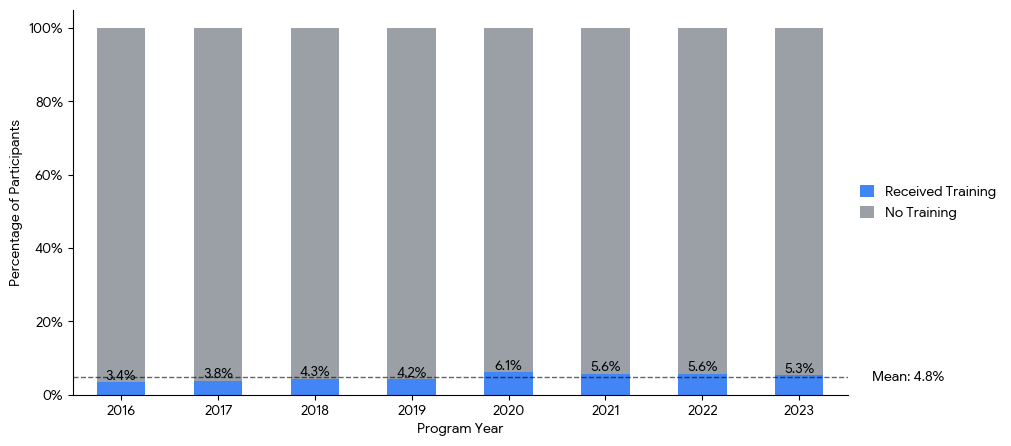

In [103]:
fig = plt.figure(
    figsize=(10, 5),
)

colormap = {
    "true": color_palette["medium_blue"],
    "false": color_palette["grey"],
}

labels_map = {
    "true": "Received Training",
    "false": "No Training"
}

colors = [colormap[col] for col in df_pivot.columns if col != "program_year"]

ax = fig.add_subplot(111)
df_pivot.plot(x='program_year', kind='bar', stacked=True, color=colors, ax=ax)

yearly_mean = df_pivot["true"].mean()
ax.axhline(y=yearly_mean, color='black', linestyle='--', linewidth=1, alpha=0.6)

ax.text(len(df_pivot) - 0.25, yearly_mean,
        f'Mean: {yearly_mean:.1f}%',
        va='center',
        ha='left',
        fontweight='bold',
        fontsize=10,
        color='black')

ax.bar_label(ax.containers[0], fmt="{:,.1f}%", fontsize=10)

ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))

ax.set_xlabel("Program Year")
ax.set_ylabel("Percentage of Participants")

handles, labels = ax.get_legend_handles_labels()
labels = [labels_map.get(label, label) for label in labels]
ax.legend(
    handles,
    labels,
    bbox_to_anchor=(1, 0.5),
    loc='center left',
    frameon=False,
    handlelength=1,
    handleheight=1
)


sns.despine()

fig.savefig("image-11.png", dpi=300, bbox_inches='tight')


## Participants by Training Service Type

In [ ]:
query = """
  SELECT
    received_training,
    training_service_1,
    COUNT(unique_id) AS participants,
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  GROUP BY training_service_1, received_training
  ORDER BY participants
  ;
"""

df = query_bq(query)

In [ ]:
training_service_map = {
  1: "On the Job Training (non-WIOA Youth)",
  2: "Skill Upgrading",
  3: "Entrepreneurial Training (non-WIOA Youth)",
  4: "ABE or ESL (contextualized or other) in conjunction with Training",
  5: "Customized Training",
  6: "Occupational Skills Training (non-WIOA Youth)",
  7: "ABE or ESL (contextualized or other) NOT in conjunction with training (funded by Trade Adjustment Assistance only)",
  8: "Prerequisite Training",
  9: "Registered Apprenticeship",
  10: "Youth Occupational Skills Training",
  11: "Other Non-Occupational-Skills Training",
  12: "Job Readiness Training in conjunction with other training",
  00: "No Training Service",
}

df = df.with_columns(
    pl.col("training_service_1").replace_strict(training_service_map, default=None)
)

In [ ]:
df_pivot = df.pivot(on="received_training", values="participants", aggregate_function="sum")

# columns_to_sum = [c for c in df_pivot.columns if c != "program_year"]

# df_pivot = df_pivot.with_columns(
#     (pl.col(columns_to_sum) / pl.sum_horizontal(columns_to_sum)) * 100
# ).to_pandas()

In [ ]:
df.group_by("received_training").agg(pl.col("participants").sum())

received_training,participants
bool,i64
false,22686072
true,1080849


In [ ]:
df_pivot = df.filter(
    pl.col("received_training")
).group_by("training_service_1").agg(pl.col("participants").sum())

<Axes: xlabel='training_service_1'>

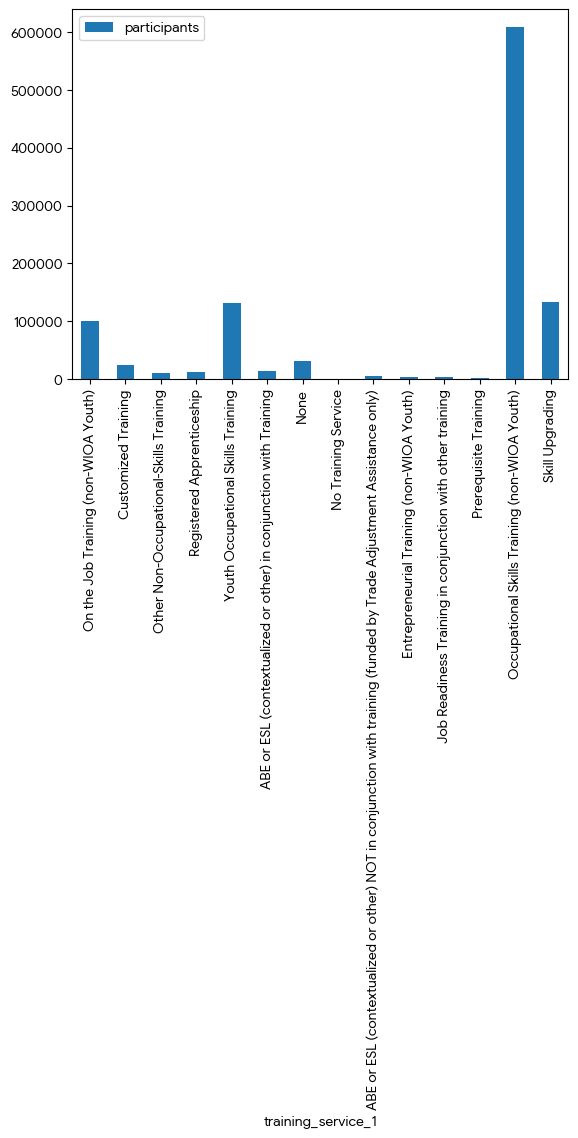

In [ ]:
df_pivot.to_pandas().plot(kind="bar", x="training_service_1", y="participants", stacked=True)

## Employment Status by Age

In [96]:
query = """
  SELECT
    employment_status,
    age,
    COUNT(unique_id) AS participants,
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
    AND received_training
    AND age >= 18 AND age < 67
  GROUP BY employment_status, age
  ORDER BY age
  ;
"""

df = query_bq(query)

df = df.drop_nulls()

In [97]:
employment_status_map = {
    1: "Employed",
    2: "Employed, but Notice of Termination",
    3: "Not in labor force",
    0: "Unemployed"
}

df_pivot = df.with_columns(
    pl.col("employment_status")
    .replace_strict(employment_status_map, default=None)
).pivot(on="employment_status", values="participants", index="age", aggregate_function="sum").fill_null(0)

columns_to_sum = [c for c in df_pivot.columns if c != "age"]

df_pivot = df_pivot.with_columns(
    (pl.col(columns_to_sum) / pl.sum_horizontal(columns_to_sum)) * 100
).to_pandas()

df_pivot = df_pivot[["age", "Unemployed", "Employed", "Employed, but Notice of Termination", "Not in labor force"]]

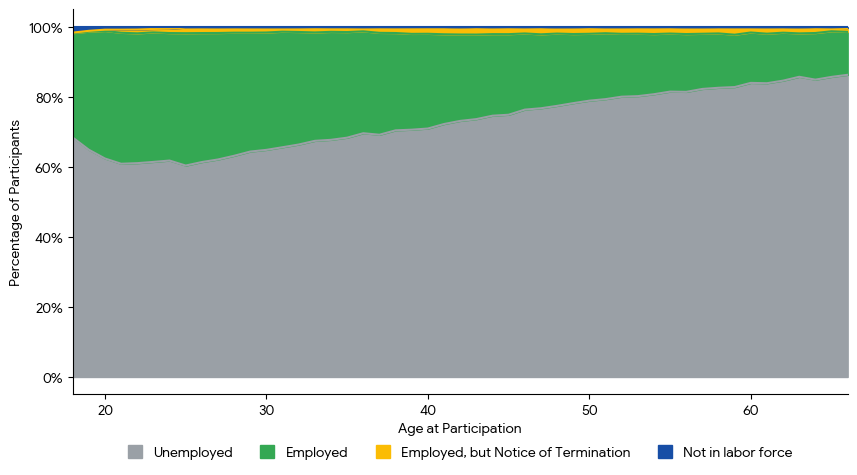

In [99]:
fig = plt.figure(
    figsize=(10, 5),
)

colormap = {
    "Not in labor force": color_palette["blue"],
    "Unemployed": color_palette["grey"],
    "Employed, but Notice of Termination": color_palette["yellow"],
    "Employed": color_palette["medium_green"]
}

colors = [colormap[col] for col in df_pivot.columns if col != "age"]

ax = fig.add_subplot(111)
df_pivot.plot(x='age', kind='area', stacked=True, color=colors, ax=ax)

# ax.bar_label(ax.containers[0], fmt="{:,.1f}%", fontsize=10)

ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))

ax.set_xlabel("Age at Participation")
ax.set_ylabel("Percentage of Participants")

handles, labels = ax.get_legend_handles_labels()
labels = [feature_mapping["employment_status"].get(label, label) for label in labels]
ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.10),
    loc='upper center',
    ncols=len(labels),
    frameon=False,
    handlelength=1,
    handleheight=1
)

ax.set_xlim(18, 66)

sns.despine()

fig.savefig("image-9.png", dpi=300, bbox_inches='tight')

## Participants by Education

In [104]:
query = """
(
  SELECT
    received_training,
    highest_educational_level,
    race,
    COUNT(unique_id) AS participants,
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  GROUP BY received_training, highest_educational_level, race
  ORDER BY participants
)

  UNION ALL

(
  SELECT
    received_training,
    highest_educational_level,
    8 AS race,
    COUNT(unique_id) AS participants,
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  GROUP BY received_training, highest_educational_level, race
  ORDER BY participants
)
"""

df = query_bq(query)

In [105]:
race_map = {
    1: "Hispanic",
    2: "Asian",
    3: "Black",
    4: "Native Hawaiian or Pacific Islander",
    5: "American Indian or Alaska Native",
    6: "White",
    7: "Multiple Race",
    8: "All"
}

highest_educational_level_map = {
    # High School or Less
    0: "High School or Less",            # No Educational Level Completed
    1: "High School or Less",            # Secondary School Diploma or Equivalency
    2: "High School or Less",            # Secondary School Diploma or Equivalency
    3: "High School or Less",            # Individualized Education Program (IEP)

    # Some College or Associate's
    4: "Some College or Associate's",    # +1 Year of Postsecondary Education
    5: "Some College or Associate's",    # Postsecondary Vocational Certificate
    6: "Some College or Associate's",    # Associate's Degree

    # Bachelor's & Beyond
    7: "Bachelor's & Beyond",            # Bachelor's Degree
    8: "Bachelor's & Beyond"             # Degree beyond Bachelor's degree
}

df = df.with_columns(
    pl.col("race").replace_strict(race_map, default=None),
    pl.col("highest_educational_level").replace_strict(highest_educational_level_map, default=None)
)

df = df.drop_nulls()

In [106]:
df_pivot = df.pivot(on="highest_educational_level", values="participants", index="race", aggregate_function="sum")

columns_to_sum = [c for c in df_pivot.columns if c != "race"]

df_pivot = df_pivot.with_columns(
    (pl.col(columns_to_sum) / pl.sum_horizontal(columns_to_sum)) * 100
).to_pandas()

df_pivot = df_pivot.sort_values(by="High School or Less")



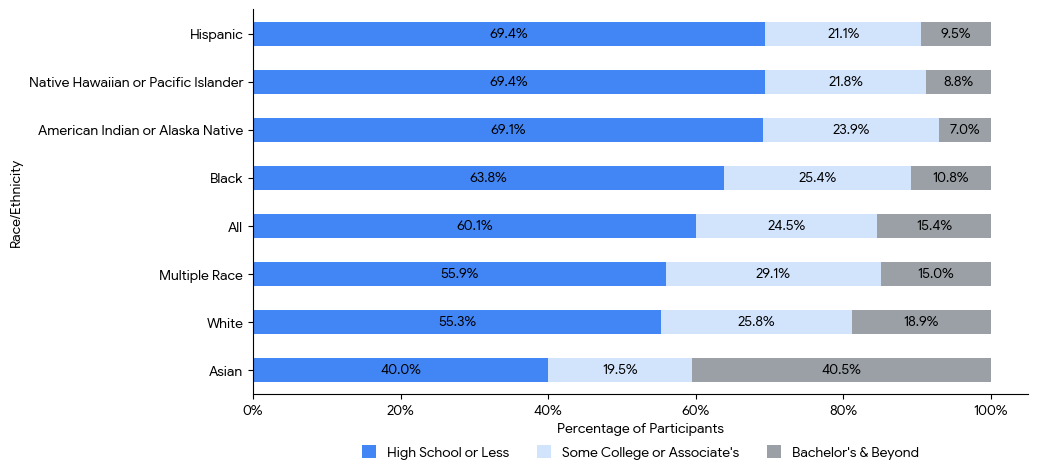

In [108]:
columns = [
    "race",
    "High School or Less",
    "Some College or Associate's",
    "Bachelor's & Beyond"
]

fig = plt.figure(
    figsize=(10, 5),
    # FigureClass=TitledFigure,
    # title="WIOA Participants are primarily middle-skill across all demographics",
    # subtitle="For five out of seven demographic groups, over 55% of the participants lack postsecondary experience.",
)

colormap = {
    "High School or Less": color_palette["medium_blue"],
    "Some College or Associate's": color_palette["light_blue"],
    "Bachelor's & Beyond": color_palette["grey"]
}

labels_map = {
    "true": "Received Training",
    "false": "No Training"
}

colors = [colormap[col] for col in columns if col != "race"]

ax = fig.add_subplot(111)
df_pivot[columns].plot(x='race', kind='barh', stacked=True, color=colors, ax=ax)

for container in ax.containers:
  labels = [f"{(v.get_width()):0.1f}%" for v in container]
  ax.bar_label(container, labels=labels, label_type="center", fontsize=10)

# labels = [f'{(v.get_y() + v.get_height())/1e6:.1f}M' for v in ax.containers[-1]]
# ax.bar_label(ax.containers[-1], labels=labels, fontsize=10)
# ax.bar_label(ax.containers[1], fmt="{:,.1f}%", fontsize=10)

# ax.tick_params(axis='x', rotation=0)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))

ax.set_ylabel("Race/Ethnicity")
ax.set_xlabel("Percentage of Participants")

handles, labels = ax.get_legend_handles_labels()
labels = [labels_map.get(label, label) for label in labels]
ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.1),
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    handlelength=1,
    handleheight=1
)


sns.despine()

fig.savefig("image-13.png", dpi=300, bbox_inches='tight')

In [109]:
df_pivot = df.pivot(on=["highest_educational_level"], values="participants", index=["received_training", "race"], aggregate_function="sum")

columns_to_sum = [c for c in df_pivot.columns if c not in ["received_training", "race"]]

df_pivot = df_pivot.with_columns(
    (pl.col(columns_to_sum) / pl.sum_horizontal(columns_to_sum)) * 100
).to_pandas()

df_pivot = df_pivot.sort_values(by="Bachelor's & Beyond")


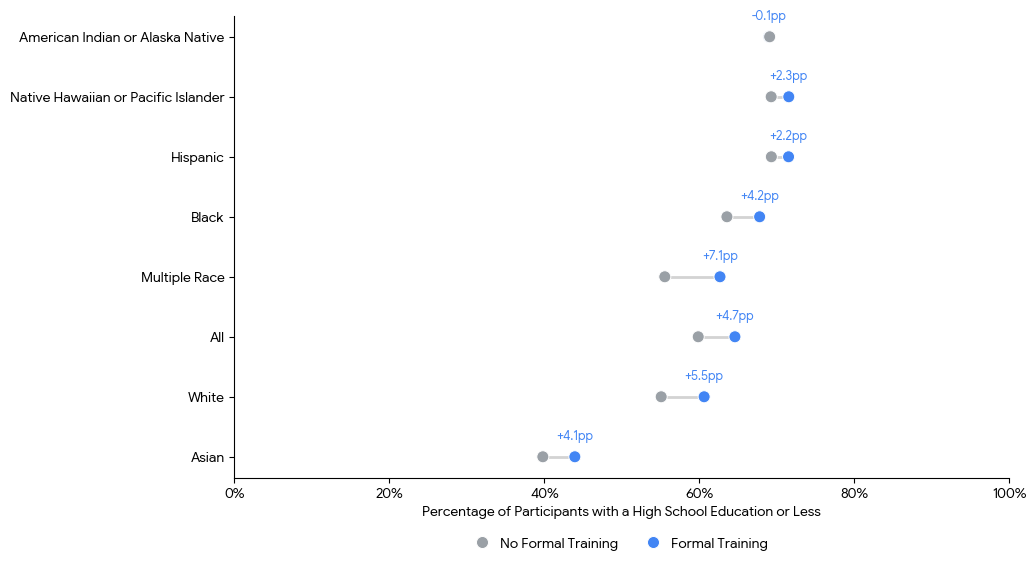

In [113]:
colormap = {
    True: color_palette["medium_blue"],
    False: color_palette["grey"],
}

labels_map = {
    'True': "Formal Training",
    'False': "No Formal Training"
}

fig = plt.figure(
    figsize=(10, 6),
    # FigureClass=TitledFigure,
    # title="A larger proportion of WIOA participants who received training have a high school education or less than those who did not receive training.",
    # subtitle="Across almost all demographic groups, the percentage of participants with a high school education or less is higher among those who received training than those who did not.",
)

ax = fig.add_subplot(111)

# 1. Create the Dumbbell Lines
for race in df_pivot["race"].unique():
    race_data = df_pivot[df_pivot["race"] == race]
    ax.hlines(
        y=race,
        xmin=race_data["High School or Less"].min(),
        xmax=race_data["High School or Less"].max(),
        color='lightgrey',
        linewidth=2,
        zorder=1
    )

    # 2. Add the Annotations
    # Logic: Find the 'True' and 'False' values to calculate the delta
    try:
        val_true = race_data[race_data["received_training"] == True]["High School or Less"].values[0]
        val_false = race_data[race_data["received_training"] == False]["High School or Less"].values[0]
        diff = val_true - val_false

        # Place text above the 'True' point
        ax.annotate(
            f"{diff:+.1f}pp",
            xy=(val_true, race),
            xytext=(0, 10), # 10 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            color=color_palette["medium_blue"]
        )
    except IndexError:
        # Handles cases where a race might be missing one of the two categories
        continue

# 3. Plot the Scatter Points
sns.scatterplot(
    data=df_pivot,
    x="High School or Less",
    y="race",
    hue="received_training",
    s=75,
    zorder=2,
    palette=colormap,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
labels = [labels_map.get(label, label) for label in labels]
ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.1),
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    handlelength=1,
    handleheight=1
)

# Clean up
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of Participants with a High School Education or Less")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))

sns.despine()

fig.savefig("image-13.png", dpi=300, bbox_inches='tight')

## Wages

In [10]:
query = """
  SELECT DISTINCT
    program_year,
    received_training,
    PERCENTILE_DISC(wages_mean_pre, 0.5) OVER(
      PARTITION BY program_year, received_training
    ) AS median
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  ORDER BY program_year
;
"""

df = query_bq(query)

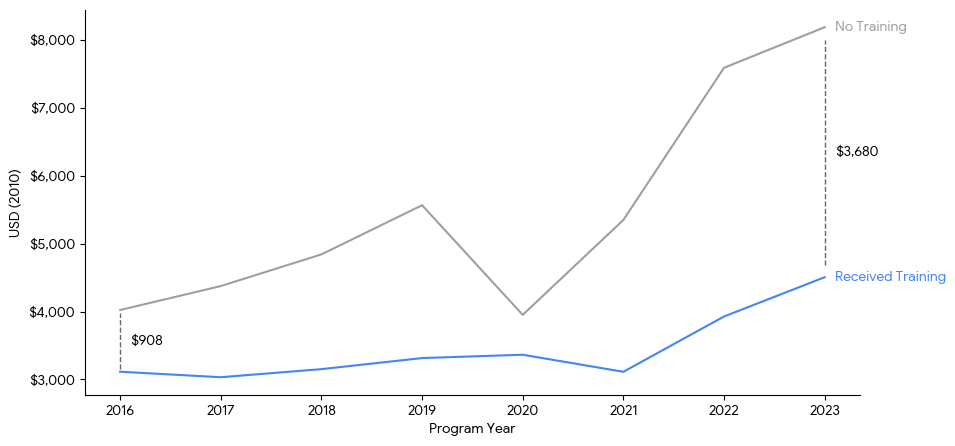

In [17]:
col = "wages_mean_post"

colors_map = {True: "#4285F4", False: "#9AA0A6"}

labels_map = {
    True: "Received Training",
    False: "No Training"
}

fig = plt.figure(
    figsize=(10, 5),
)

# 1. Setup Data for Annotations
# Assuming df is sorted by year; get the first and last years
start_year = df['program_year'].min()
end_year = df['program_year'].max()

def add_diff_annotation(ax, year, x_offset=0):
    # Find the y-values for both groups at this specific year
    y_vals = df.filter(pl.col("program_year") == year)["median"]
    y_trained = y_vals[1]
    y_control = y_vals[0]
    diff = y_trained - y_control
    if diff > 0:
      ymin = y_control
      ymax = y_trained
    else:
      ymin = y_trained
      ymax = y_control

    y_offset = np.abs(diff) * 0.05

    # Draw a vertical dashed line between the two points
    ax.vlines(x=year + x_offset, ymin=ymin + y_offset, ymax=ymax - y_offset,
              color='black', linestyle='--', linewidth=1, alpha=0.6)

    # Add the text label (the difference)
    # Formatted as +$X,XXX
    ax.text(year + x_offset + 0.1, (y_trained + y_control) / 2,
            f'${np.abs(diff):,.0f}',
            va='center', fontweight='bold', fontsize=10)

ax = fig.add_subplot(111)
sns.lineplot(df, x="program_year", y="median", hue="received_training", palette=colors_map, ax=ax)

# Get the last x-value to position the text
last_year = df['program_year'].max()

# Iterate through the groups to place labels
for line, name in zip(ax.lines, df['received_training'].unique()):
    # Update the label name
    name = labels_map.get(name, name)

    # Get the last y-value for this specific line
    y_pos = line.get_ydata()[-1]

    # Add text: last_year + small offset, y_position, label name
    ax.text(last_year + 0.1, y_pos, name,
            color=line.get_color(), va='center', fontweight='bold')

# Remove the default legend as it's now redundant
ax.get_legend().remove()

# 3. Add the annotations at start and end
add_diff_annotation(ax, start_year, x_offset=-0) # Shift left slightly
add_diff_annotation(ax, end_year, x_offset=0)    # Shift right slightly

ax.set_xlabel("Program Year")
ax.set_ylabel("USD (2010)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

sns.despine()

fig.savefig("image-14.png", dpi=300)

In [18]:
query = """
  SELECT DISTINCT
    program_year,
    received_training,
    PERCENTILE_DISC(wages_mean_diff, 0.5) OVER(
      PARTITION BY program_year, received_training
    ) AS median
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  ORDER BY program_year
;
"""

df = query_bq(query)

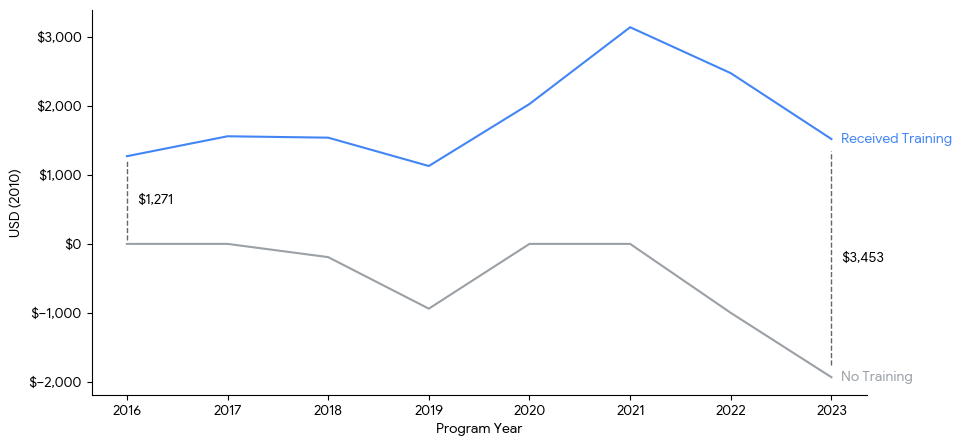

In [19]:
colors_map = {True: "#4285F4", False: "#9AA0A6"}

labels_map = {
    True: "Received Training",
    False: "No Training"
}

fig = plt.figure(
    figsize=(10, 5),
)

# 1. Setup Data for Annotations
# Assuming df is sorted by year; get the first and last years
start_year = df['program_year'].min()
end_year = df['program_year'].max()

def add_diff_annotation(ax, year, x_offset=0):
    # Find the y-values for both groups at this specific year
    y_vals = df.filter(pl.col("program_year") == year)["median"]
    y_trained = y_vals[1]
    y_control = y_vals[0]
    diff = y_trained - y_control
    if diff > 0:
      ymin = y_control
      ymax = y_trained
    else:
      ymin = y_trained
      ymax = y_control

    y_offset = np.abs(diff) * 0.05

    # Draw a vertical dashed line between the two points
    ax.vlines(x=year + x_offset, ymin=ymin + y_offset, ymax=ymax - y_offset,
              color='black', linestyle='--', linewidth=1, alpha=0.6)

    # Add the text label (the difference)
    # Formatted as +$X,XXX
    ax.text(year + x_offset + 0.1, (y_trained + y_control) / 2,
            f'${np.abs(diff):,.0f}',
            va='center', fontweight='bold', fontsize=10)

ax = fig.add_subplot(111)
sns.lineplot(df, x="program_year", y="median", hue="received_training", palette=colors_map, ax=ax)

# Get the last x-value to position the text
last_year = df['program_year'].max()

# Iterate through the groups to place labels
for line, name in zip(ax.lines, df['received_training'].unique()):
    # Update the label name
    name = labels_map.get(name, name)

    # Get the last y-value for this specific line
    y_pos = line.get_ydata()[-1]

    # Add text: last_year + small offset, y_position, label name
    ax.text(last_year + 0.1, y_pos, name,
            color=line.get_color(), va='center', fontweight='bold')

# Remove the default legend as it's now redundant
ax.get_legend().remove()

# 3. Add the annotations at start and end
add_diff_annotation(ax, start_year, x_offset=-0) # Shift left slightly
add_diff_annotation(ax, end_year, x_offset=0)    # Shift right slightly

ax.set_xlabel("Program Year")
ax.set_ylabel("USD (2010)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

sns.despine()

fig.savefig("image-15.png", dpi=300)

In [ ]:
query = """
  SELECT
    wages_mean_pre,
    wages_mean_post,
    wages_mean_diff,
    received_training
  FROM `retraining-index.fact.performance_records`
  TABLESAMPLE SYSTEM (10 PERCENT)
  WHERE program_year < 2024
;
"""

df = query_bq(query)

In [ ]:
epsilon = 0
df = df.filter(
    (pl.col("wages_mean_pre") > 0) &
    (pl.col("wages_mean_post") > 0)
).with_columns(
    (pl.col("wages_mean_pre") + epsilon).log10().alias("wages_mean_pre_log"),
    (pl.col("wages_mean_post") + epsilon).log10().alias("wages_mean_post_log")
).with_columns(
    (pl.col("wages_mean_post_log") - pl.col("wages_mean_pre_log")).alias("wages_mean_diff_log")
)

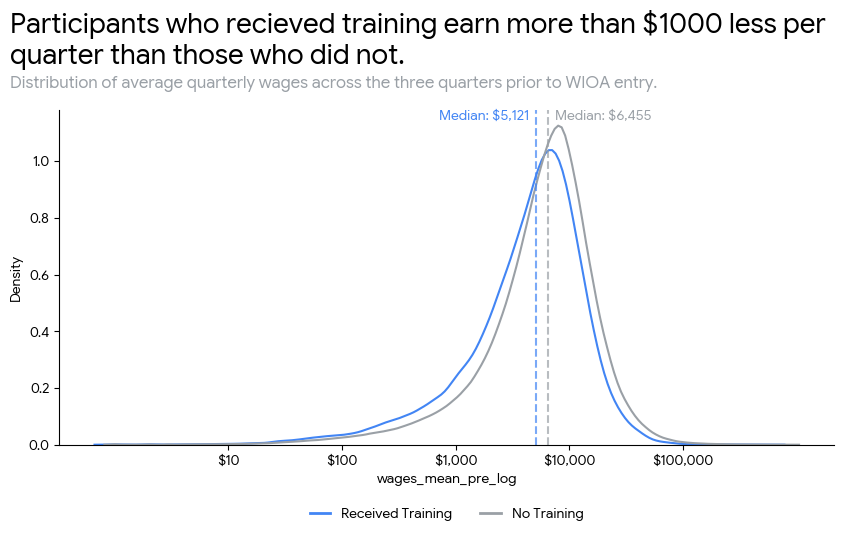

In [ ]:
colors_map = {True: "#4285F4", False: "#9AA0A6"}
labels_map = {True: "Received Training", False: "No Training"}

fig = plt.figure(
    figsize=(10, 5),
    FigureClass=TitledFigure,
    title="Participants who recieved training earn more than $1000 less per quarter than those who did not.",
    subtitle="Distribution of average quarterly wages across the three quarters prior to WIOA entry.",
)

ax = sns.kdeplot(
    data=df,
    x="wages_mean_pre_log",
    hue="received_training",
    common_norm=False,
    palette=colors_map,
    legend=False
)

# 1. Calculate Meidan and Annotate
for is_trained, label in labels_map.items():
    # Filter data and calculate median
    median_val = df.filter(pl.col("received_training") == is_trained)["wages_mean_pre_log"].median()
    color = colors_map[is_trained]

    # Draw vertical line
    ax.axvline(median_val, color=color, linestyle="--", alpha=0.7)

    # logic to split alignment: True (Blue) to the left, False (Grey) to the right
    # You can flip these if the blue line is actually to the right of the grey line
    alignment = 'right' if is_trained else 'left'
    offset = -5 if is_trained else 5

    ax.annotate(
        f"Median: ${10 ** median_val:,.0f}",
        xy=(median_val, 1),
        xycoords=ax.get_xaxis_transform(),
        color=color,
        fontweight='bold',
        ha=alignment,
        va='top',
        xytext=(offset, 0),
        textcoords='offset points'
    )
# 2. Change X-axis to show 1, 10, 100, etc.
# Since the data is log-transformed, we format the ticks as e^x
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${10 ** x:,.0f}'))

# Set ticks at specific log intervals (log(1)=0, log(10)=2.3, log(100)=4.6, etc.)
# Or use a fixed range if you know your wage bounds:
tick_values = [0, 1, 2, 3, 4, 5]
ax.set_xticks([v for v in tick_values if v > 0])

# 3. Manually construct the legend to ensure labels match the colors
from matplotlib.lines import Line2D

custom_handles = [
    Line2D([0], [0], color=colors_map[True], lw=2),
    Line2D([0], [0], color=colors_map[False], lw=2)
]
custom_labels = [labels_map[True], labels_map[False]]

ax.legend(
    custom_handles,
    custom_labels,
    bbox_to_anchor=(0.5, -0.15), # Dropped slightly lower to avoid overlap
    loc='upper center',
    ncol=2,
    frameon=False,
    handlelength=1.5
)

ax.set

fig.finalize_layout()

## Outcomes by Received Training

In [ ]:
query = """
  SELECT
    received_training,
    COUNT(*) AS participants,
    AVG(CASE WHEN index > 0.5 THEN 1 ELSE 0 END) AS mean_index,
    AVG(wages_mean_diff) AS mean_diff_wages,
    AVG(diff_r_cog_subsector) AS mean_diff_r_cog_subsector,
    AVG(diff_r_man_subsector) AS mean_diff_r_man_subsector
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND received_training IS NOT NULL
    AND index IS NOT NULL
    AND wages_mean_diff IS NOT NULL
    AND diff_r_cog_subsector IS NOT NULL
    AND diff_r_man_subsector IS NOT NULL
  GROUP BY received_training
;
"""

df = query_bq(query)

In [ ]:
df

received_training,participants,mean_index,mean_diff_wages,mean_diff_r_cog_subsector,mean_diff_r_man_subsector
bool,i64,f64,f64,f64,f64
false,10909107,0.4933,-1165.613636,-0.000873,-0.00348
true,473449,0.644897,2423.102277,0.02909,0.035448


In [ ]:
df.transpose(include_header=True, column_names=["Received Training", "No Training"])

column,Received Training,No Training
str,f64,f64
"""received_training""",0.0,1.0
"""participants""",1.0909107e7,473449.0
"""mean_index""",0.4933,0.644897
"""mean_diff_wages""",-1165.613636,2423.102277
"""mean_diff_r_cog_subsector""",-0.000873,0.02909
"""mean_diff_r_man_subsector""",-0.00348,0.035448


In [ ]:
query = """
  SELECT
    program_year,
    received_training,
    AVG(CASE WHEN diff_r_man_subsector < 0 THEN 1 ELSE 0 END) AS median,
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND received_training IS NOT NULL
    AND index IS NOT NULL
    AND wages_mean_diff IS NOT NULL
    AND diff_r_cog_subsector IS NOT NULL
    AND diff_r_man_subsector IS NOT NULL
  GROUP BY program_year, received_training
  ORDER BY program_year
;
"""

df = query_bq(query)

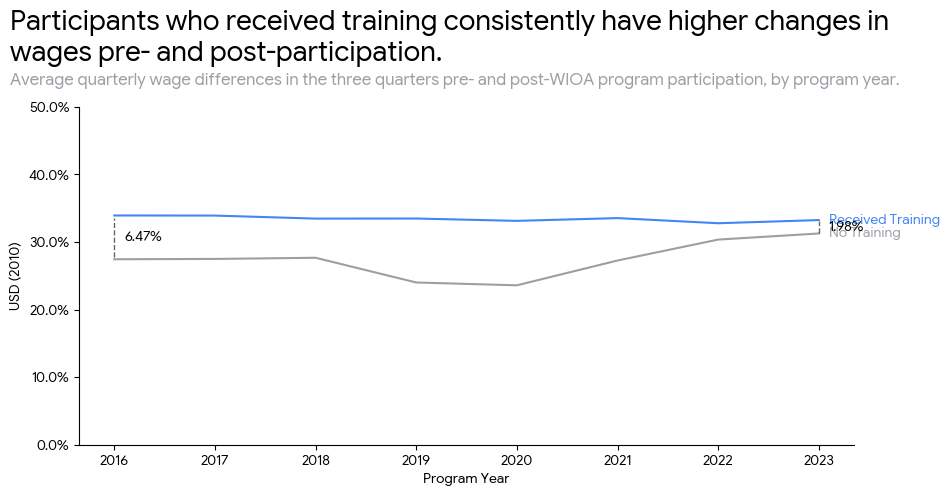

In [ ]:
colors_map = {True: "#4285F4", False: "#9AA0A6"}

labels_map = {
    True: "Received Training",
    False: "No Training"
}

fig = plt.figure(
    figsize=(10, 5),
    FigureClass=TitledFigure,
    title="Participants who received training consistently have higher changes in wages pre- and post-participation.",
    subtitle="Average quarterly wage differences in the three quarters pre- and post-WIOA program participation, by program year.",
)

# 1. Setup Data for Annotations
# Assuming df is sorted by year; get the first and last years
start_year = df['program_year'].min()
end_year = df['program_year'].max()

def add_diff_annotation(ax, year, x_offset=0):
    # Find the y-values for both groups at this specific year
    y_vals = df.filter(pl.col("program_year") == year)["median"]
    y_trained = y_vals[1]
    y_control = y_vals[0]
    diff = y_trained - y_control
    if diff > 0:
      ymin = y_control
      ymax = y_trained
    else:
      ymin = y_trained
      ymax = y_control

    y_offset = np.abs(diff) * 0.05

    # Draw a vertical dashed line between the two points
    ax.vlines(x=year + x_offset, ymin=ymin + y_offset, ymax=ymax - y_offset,
              color='black', linestyle='--', linewidth=1, alpha=0.6)

    # Add the text label (the difference)
    # Formatted as +$X,XXX
    ax.text(year + x_offset + 0.1, (y_trained + y_control) / 2,
            f'{np.abs(diff):,.2%}',
            va='center', fontweight='bold', fontsize=10)

ax = fig.add_subplot(111)
sns.lineplot(df, x="program_year", y="median", hue="received_training", palette=colors_map, ax=ax)

# Get the last x-value to position the text
last_year = df['program_year'].max()

# Iterate through the groups to place labels
for line, name in zip(ax.lines, df['received_training'].unique()):
    # Update the label name
    name = labels_map.get(name, name)

    # Get the last y-value for this specific line
    y_pos = line.get_ydata()[-1]

    # Add text: last_year + small offset, y_position, label name
    ax.text(last_year + 0.1, y_pos, name,
            color=line.get_color(), va='center', fontweight='bold')

# Remove the default legend as it's now redundant
ax.get_legend().remove()

ax.set_ylim(0, 0.5)


# 3. Add the annotations at start and end
add_diff_annotation(ax, start_year, x_offset=-0) # Shift left slightly
add_diff_annotation(ax, end_year, x_offset=0)    # Shift right slightly

ax.set_xlabel("Program Year")
ax.set_ylabel("USD (2010)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.1%}'))
# IMPORTANT: finalize after axes exist
fig.finalize_layout()

plt.show()


## Positive Outcomes by Index Subcomponent

In [ ]:
query = """
  SELECT
    received_training,
    AVG(CASE WHEN index_subsector > 0.5 THEN 1 ELSE 0 END) AS index_subsector_pos,
    AVG(CASE WHEN wages_mean_diff_normalized > 0.5 THEN 1 ELSE 0 END) AS wages_pos,
    AVG(CASE WHEN diff_r_cog_subsector_normalized < 0.5 THEN 1 ELSE 0 END) AS r_cog_pos,
    AVG(CASE WHEN diff_r_man_subsector_normalized < 0.5 THEN 1 ELSE 0 END) AS r_man_pos,
    COUNTIF(index_subsector IS NOT NULL) AS n
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND index_subsector IS NOT NULL
  GROUP BY received_training
  ORDER BY received_training
;
"""

df = query_bq(query)

In [ ]:
received_training_map = {
    True: "Formal Training",
    False: "No Formal Training"
}

df = df.with_columns(
    pl.col("received_training").replace_strict(received_training_map)
).rename(
    {
        "received_training": "Received Training",
        "wages_pos": "Wage Change",
        "r_cog_pos": "RTI Change (Cognitive)",
        "r_man_pos": "RTI Change (Manual)"
    }
)

In [ ]:
df = df.unpivot(
    on=["Wage Change", "RTI Change (Cognitive)", "RTI Change (Manual)"],
    index=["Received Training"],
    variable_name="Index Subcomponent",
    value_name="Proportion"
)

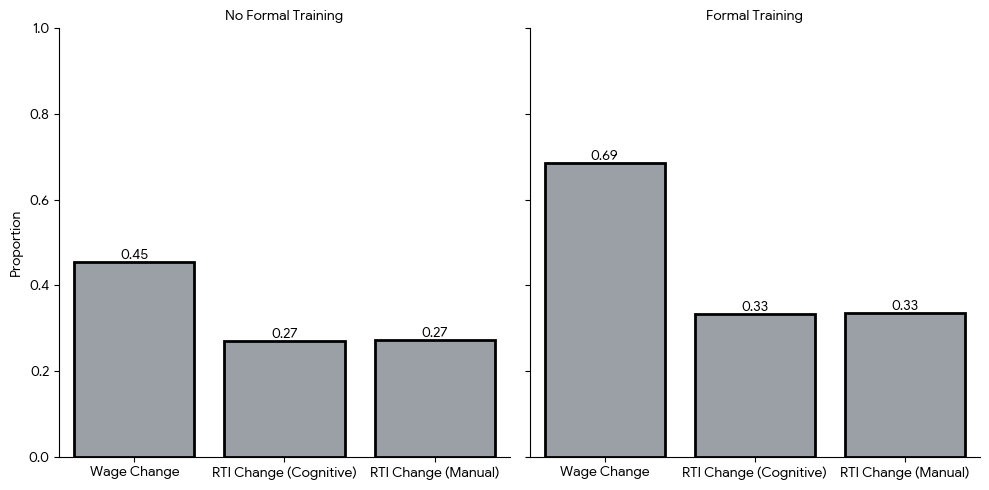

In [ ]:
g = sns.FacetGrid(df, col="Received Training", height=5)

# Map the barplot with no fill and black outline
g.map_dataframe(sns.barplot, y="Proportion", x="Index Subcomponent",
                facecolor=color_palette['grey'], edgecolor='black', linewidth=2)

# Remove x-axis labels
g.set_axis_labels("", "Proportion")

# Add bar labels using the built-in method
for ax in g.axes.flat:
    # Get the container of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

g.set_titles(col_template="{col_name}")
g.set(ylim=(0, 1))


plt.tight_layout()

## Index by State

In [ ]:
query = """
  SELECT
    state,
    AVG(CASE WHEN index_subsector > 0.5 THEN 1 ELSE 0 END) AS incidence,
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND index_subsector IS NOT NULL
    AND received_training
  GROUP BY state
  ORDER BY state
;
"""

df = query_bq(query)

In [ ]:
df

state,incidence
str,f64
"""AK""",0.705948
"""AL""",0.648862
"""AR""",0.672448
"""AZ""",0.632436
"""CA""",0.63736
…,…
"""VT""",0.610526
"""WA""",0.593424
"""WI""",0.630941


In [ ]:
from shapely.affinity import scale, translate
import pandas as pd


In [ ]:
url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_1_states_provinces_shp.geojson"
df_states = gpd.read_file(url)

# us = df_states[df_states["adm0_a3"] == "USA"].copy()

df_states = df_states.to_crs(epsg=5070)
df_states = df_states.merge(df.to_pandas(), left_on="postal", right_on="state", how="left")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Polygon
import missingno as msno
import os
import openpyxl
import math


def makeColorColumn(gdf,variable,vmin,vmax):
    # apply a function to a column to create a new column of assigned colors & return full frame
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    mapper = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.YlOrBr)
    gdf['value_determined_color'] = gdf[variable].apply(lambda x: mcolors.to_hex(mapper.to_rgba(x)))
    return gdf

/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipython-input-1293417555.py:67: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  alaska_gdf.clip(polygon).plot(color=gdf[gdf.postal=='AK'].value_determined_color, linewidth=0.8,ax=akax, edgecolor='0.8')
/tmp/ipython-input-1293417555.py:76: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  hawaii_gdf.clip(hipolygon).plot(column=variable, color=hawaii_gdf['value_determined_color'], linewidth=0.8,ax=hiax, edgecolor='0.8')
/tmp/ipython-input-1293417555.py:76: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has 

<Axes: >

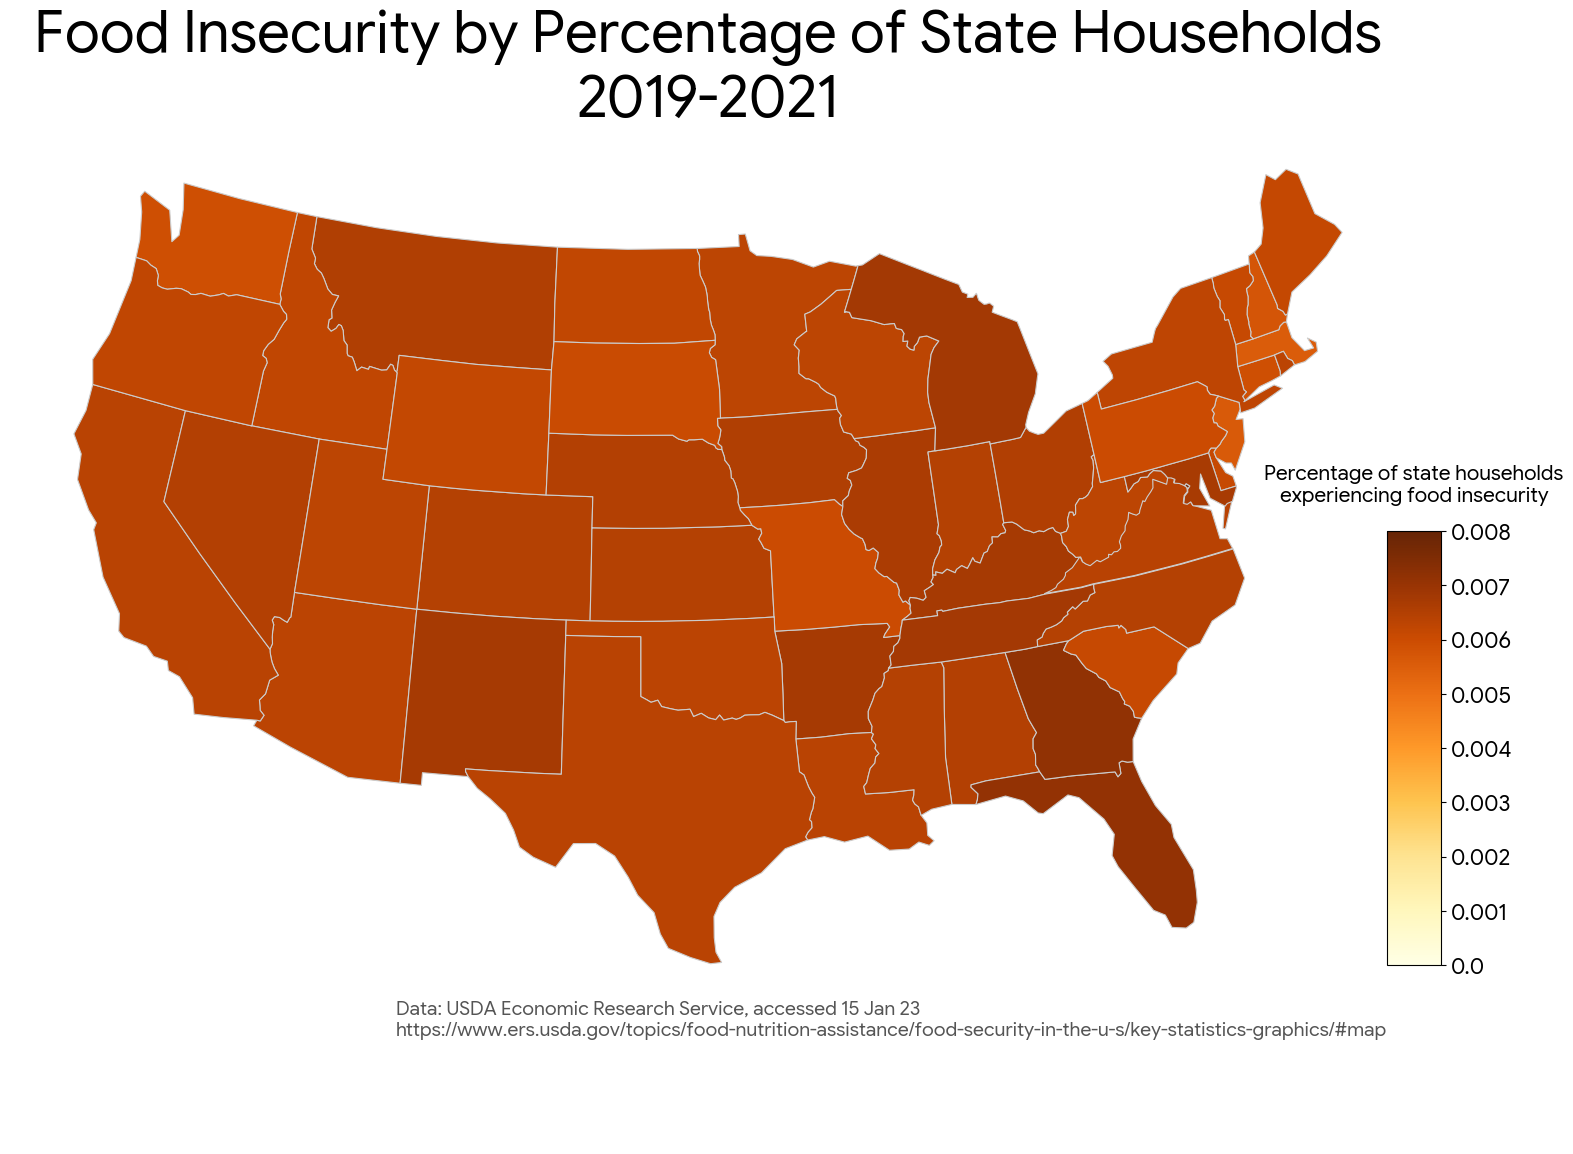

In [ ]:
# **************************
# set the value column that will be visualised
variable = 'incidence'
gdf = df_states

# make a column for value_determined_color in gdf
# set the range for the choropleth values with the upper bound the rounded up maximum value
vmin, vmax = 0, 0.8
# Choose the continuous colorscale "YlOrBr" from https://matplotlib.org/stable/tutorials/colors/colormaps.html
colormap = "YlOrBr"
gdf = makeColorColumn(gdf,variable,vmin,vmax)

# create "visframe" as a re-projected gdf using EPSG 2163 for CONUS
visframe = gdf.to_crs({'init':'epsg:2163'})



# create figure and axes for Matplotlib
fig, ax = plt.subplots(1, figsize=(18, 14))
# remove the axis box around the vis
ax.axis('off')

# # set the font for the visualization to Helvetica
hfont = {'fontname':'Google Sans Flex 24pt'}

# add a title and annotation
ax.set_title('Food Insecurity by Percentage of State Households\n2019-2021', **hfont, fontdict={'fontsize': '42', 'fontweight' : '1'})

# Create colorbar legend
fig = ax.get_figure()
# add colorbar axes to the figure
# This will take some iterating to get it where you want it [l,b,w,h] right
# l:left, b:bottom, w:width, h:height; in normalized unit (0-1)
cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])

cbax.set_title('Percentage of state households\nexperiencing food insecurity\n', **hfont, fontdict={'fontsize': '15', 'fontweight' : '0'})

# add color scale
sm = plt.cm.ScalarMappable(cmap=colormap, \
                 norm=plt.Normalize(vmin=vmin, vmax=vmax))
# reformat tick labels on legend
sm._A = []
comma_fmt = FuncFormatter(lambda x, p: format(x/100, '.2'))
fig.colorbar(sm, cax=cbax, format=comma_fmt)
tick_font_size = 16
cbax.tick_params(labelsize=tick_font_size)
# annotate the data source, date of access, and hyperlink
ax.annotate("Data: USDA Economic Research Service, accessed 15 Jan 23\nhttps://www.ers.usda.gov/topics/food-nutrition-assistance/food-security-in-the-u-s/key-statistics-graphics/#map", xy=(0.22, .085), xycoords='figure fraction', fontsize=14, color='#555555')


# create map
# Note: we're going state by state here because of unusual coloring behavior when trying to plot the entire dataframe using the "value_determined_color" column
for row in visframe.itertuples():
    if row.postal not in ['AK','HI']:
        vf = visframe[visframe.postal==row.postal]
        c = gdf[gdf.postal==row.postal][0:1].value_determined_color.item()
        vf.plot(color=c, linewidth=0.8, ax=ax, edgecolor='0.8')



# add Alaska
akax = fig.add_axes([0.1, 0.17, 0.2, 0.19])
akax.axis('off')
# polygon to clip western islands
polygon = Polygon([(-170,50),(-170,72),(-140, 72),(-140,50)])
alaska_gdf = gdf[gdf.postal=='AK']
alaska_gdf.clip(polygon).plot(color=gdf[gdf.postal=='AK'].value_determined_color, linewidth=0.8,ax=akax, edgecolor='0.8')


# add Hawaii
hiax = fig.add_axes([.28, 0.20, 0.1, 0.1])
hiax.axis('off')
# polygon to clip western islands
hipolygon = Polygon([(-160,0),(-160,90),(-120,90),(-120,0)])
hawaii_gdf = gdf[gdf.postal=='HI']
hawaii_gdf.clip(hipolygon).plot(column=variable, color=hawaii_gdf['value_determined_color'], linewidth=0.8,ax=hiax, edgecolor='0.8')



# fig.savefig(os.getcwd()+'/food_insecurity_by_state_2019_2021.png',dpi=400, bbox_inches="tight")
# bbox_inches="tight" keeps the vis from getting cut off at the edges in the saved png
# dip is "dots per inch" and controls image quality.  Many scientific journals have specifications for this
# https://stackoverflow.com/questions/16183462/saving-images-in-python-at-a-very-high-quality

## Index by Age

In [ ]:
query = """
  SELECT
    age,
    AVG(CASE WHEN index_subsector > 0.5 THEN 1 ELSE 0 END) AS incidence,
    COUNTIF(index_subsector IS NOT NULL) AS n
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND index_subsector IS NOT NULL
  GROUP BY age
  ORDER BY age
;
"""

df = query_bq(query)

In [ ]:
df = df.filter(
    (pl.col('age') > 17) & (pl.col('age') < 67)
)

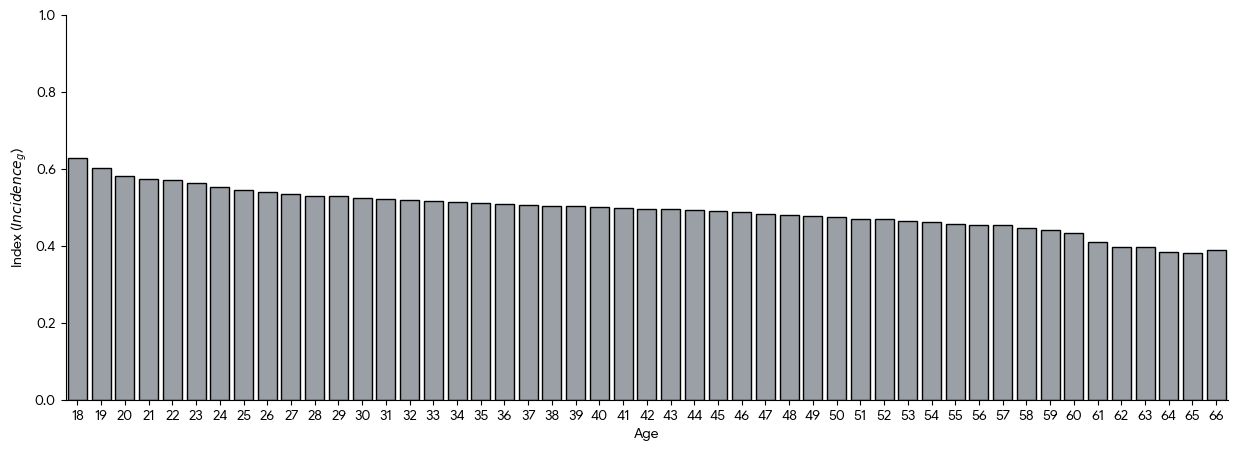

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(df, x='age', y='incidence', facecolor=color_palette['grey'], edgecolor='black', linewidth=1, ax=ax)

ax.set_xlabel("Age")

ax.set_ylabel("Index ($Incidence_g$)")
ax.set_ylim(0, 1)

sns.despine()

## Index by Employment Status

In [20]:
query = """
  SELECT
    employment_status,
    AVG(CASE WHEN index_subsector > 0.5 THEN 1 ELSE 0 END) AS incidence,
    COUNTIF(index_subsector IS NOT NULL) AS n
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND index_subsector IS NOT NULL
  GROUP BY employment_status
  ORDER BY incidence DESC
;
"""

df = query_bq(query)

In [23]:
df = df.with_columns(
    pl.col("employment_status").replace_strict(feature_mapping["employment_status"])
)

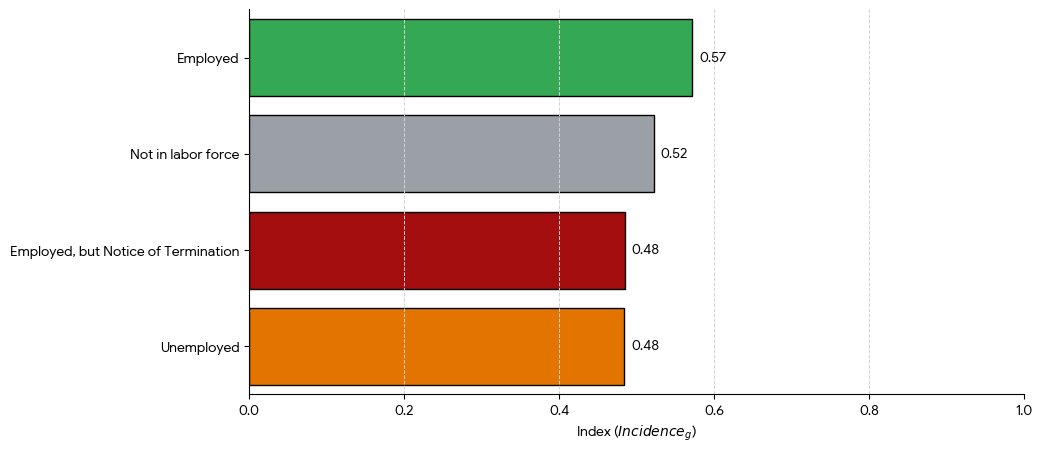

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

facecolors = [
    color_palette['medium_green'],
    color_palette['grey'],
    color_palette['red'],
    color_palette['orange']
]

sns.barplot(df, x='incidence', y='employment_status', orient='h', facecolor=facecolors, edgecolor='black', linewidth=1, ax=ax)

ax.set_ylabel("")

ax.set_xlabel("Index ($Incidence_g$)")
ax.set_xlim(0, 1)

ax.xaxis.grid(True, color="lightgray", linestyle="--", linewidth=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)


sns.despine()

## Employment Status by Age

In [87]:
query = """
  SELECT
    age,
    employment_status,
    received_training,
    COUNT(*) AS n
  FROM `retraining-index.fact.retrainability_index`
  WHERE program_year < 2024
    AND age IS NOT NULL
    AND age > 17 AND age < 67
  GROUP BY 1, 2, 3
  ORDER BY 1
;
"""

df = query_bq(query)

df = df.with_columns(
  pl.col("employment_status").replace_strict(feature_mapping["employment_status"]),
  pl.col("received_training").replace_strict(feature_mapping["received_training"])
)

In [88]:
df_pivot = (
    df
    .pivot(
      index=["age", "received_training"], on="employment_status", values="n", aggregate_function="sum"
    )
    .with_columns(
      pl.sum_horizontal(pl.all().exclude("id", "received_training")).alias("total")
    )
    .with_columns(
      [
        (pl.col(col) / pl.col("total") * 100).alias(col)
        for col in df["employment_status"].unique().to_list()
      ]
    )
    .drop("total")
    .to_pandas()
    .set_index("age")
)[["received_training", "Employed", "Employed, but Notice of Termination", "Not in labor force", "Unemployed"]]

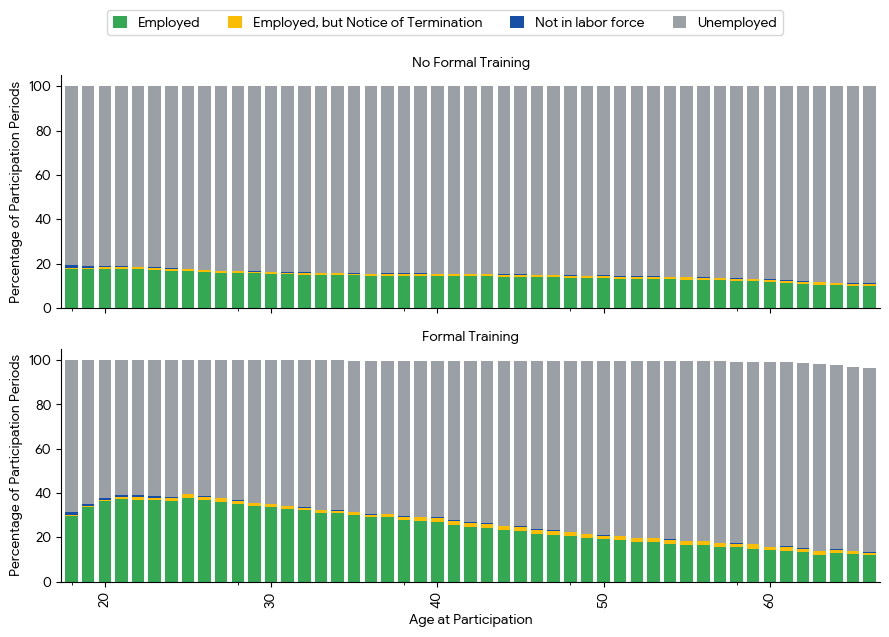

In [95]:
g = sns.FacetGrid(df_pivot, row='received_training', height=3, aspect=3)

def stackedbarplot(data, *args, **kwargs):
  facecolors = [
    color_palette['medium_green'],
    color_palette['yellow'],
    color_palette['blue'],
    color_palette['grey'],
  ]

  ax = plt.gca()

  data.plot(kind='bar', stacked=True, color=facecolors, width=0.75, ax=ax)

  ax.xaxis.set_major_locator(mticker.MultipleLocator(10, offset=2))
  ax.set_ylabel("Percentage of Participation Periods")
  ax.set_xlabel("Age at Participation")

g.map_dataframe(stackedbarplot)
g.set_titles(row_template="{row_name}")

handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.figure.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncols=4,
    handlelength=1,
    handleheight=1
)

g.figure.savefig("image-10.png", dpi=300, bbox_inches='tight')

# 4. Models

In [12]:
query = """
  SELECT
    *
  FROM `retraining-index.fact.retrainability_index` TABLESAMPLE SYSTEM (10 PERCENT)
  WHERE program_year < 2024
    AND index_subsector IS NOT NULL
;
"""

df = query_bq(query)

In [13]:
df = (
    df
    .with_columns(
        # Create indicator variable for if the index_subsector is positive
        (pl.col("index_subsector") > 0.5).alias("index_subsector_positive").cast(pl.Int8),

        # Create indicator if workforce_board_rucc is a metro county
        # or a nonmetro county with urban population of 20,000 or more
        (pl.col("workforce_board_rucc") < 5).alias("workforce_board_metro_status").cast(pl.Int8),

        # Create indicator if median income less in the bottom 10%, middle 90% or top 90%
        pl.when(pl.col("workforce_board_median_income") < pl.col("workforce_board_median_income").quantile(0.10))
          .then(pl.lit("low_income"))
        .when(pl.col("workforce_board_median_income") < pl.col("workforce_board_median_income").quantile(0.90))
          .then(pl.lit("median_income"))
        .when(pl.col("workforce_board_median_income") >= pl.col("workforce_board_median_income").quantile(0.90))
          .then(pl.lit("high_income"))
        .otherwise(None).alias("workforce_board_median_income_level")
    )
)

In [15]:
feature_name_mapping = {
    # Program Participation & Structure
    "received_training": "Received Training Indicator",
    "employment_status": "Employment Status at Entry",
    "workforce_board_code": "Local Workforce Board (WDB)",
    "occupational_code_pre": "Pre-Program Occupation",
    "program_year": "Program Year",
    "funding_stream": "Funding Stream",
    "training_service_1": "Training Service Type",

    # Demographics & Individual Characteristics
    "sex": "Sex",
    "race": "Race / Ethnicity",
    "age": "Participant Age",
    "highest_educational_level": "Highest Educational Level",
    "low_income_status": "Low Income Status",
    "state": "State",
    "r_cog_pre": "Routine Cognitive Intensity (Pre-Program)",
    "r_man_pre": "Routine Manual Intensity (Pre-Program)",

    # Regional Economic Indicators (Workforce Board Level)
    'workforce_board_population': "WDB Population",
    'workforce_board_median_age': "WDB Median Age",
    'workforce_board_unemployment_rate': "WDB Unemployment Rate",
    'workforce_board_diversity_index': "WDB Diversity Index",
    'workforce_board_household_debt_to_income_high': "WDB High Household Debt-to-Income Ratio",
    'workforce_board_mean_commuting_time_min': "WDB Mean Commuting Time (Min) ",
    'workforce_board_population_per_sqkm': "WDB Population (per sq km)",
    'workforce_board_metro_status': "WDB Metro Status",
    'workforce_board_median_income_level': "WDB Median Income Level"
}

##  Gradient Boosting (All)

In [16]:
X_columns = [
    # Program Participation & Structure
    'received_training',
    'employment_status',
    'workforce_board_code',
    'occupational_code_pre',
    'program_year',
    'funding_stream',
    'training_service_1',

    # Demographics & Individual Characteristics
    'sex',
    'race',
    'age',
    'highest_educational_level',
    'low_income_status',
    'state',
    'r_cog_pre',
    'r_man_pre',

    # Regional Economic Indicators (Workforce Board Level)
    'workforce_board_population',
    'workforce_board_median_age',
    'workforce_board_unemployment_rate',
    'workforce_board_diversity_index',
    'workforce_board_household_debt_to_income_high',
    'workforce_board_mean_commuting_time_min',
    'workforce_board_population_per_sqkm',
    'workforce_board_metro_status',
    'workforce_board_median_income_level'
]
y_column = "index_subsector_positive"

In [17]:
# Check the cardinality of categorical features
categorical_columns = ['state', 'occupational_code_pre', 'occupational_code_post',
                   'workforce_board_code', 'funding_stream', 'workforce_board_median_income_level']
for col in categorical_columns:
    print(f"{col}: {df[col].n_unique()} unique values")


# Cast categorical columns to Category type
df_data = (
    df
    .with_columns([
        pl.col(categorical_columns).cast(pl.Categorical),
    ])
)

state: 52 unique values
occupational_code_pre: 1235 unique values
occupational_code_post: 858 unique values
workforce_board_code: 640 unique values
funding_stream: 5 unique values
workforce_board_median_income_level: 4 unique values


In [18]:
# Separate featuers variables (X) and outcome variable (y)
X = df_data.select(X_columns).to_pandas()
y = df_data[y_column].to_numpy()

# Split in to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [19]:
# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50,
    n_jobs=-1,
    device="cuda",
    tree_method="hist",
    enable_categorical=True,
    verbosity=0,
)

# Hyperparameter search space for XGBoost
params = {
    "max_depth": [10, 15],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 10],
    "gamma": [0, 0.1],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=15,
    cv=3,
    n_jobs=1,
    scoring="f1_macro",
    verbose=2,
    random_state=42
)

search.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  10.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   9.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  10.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  10.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   9.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=15, min_child_weight=1, subsample=1.0; total time=  20.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_r

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=50,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.1],
                                        'max_depth': [10, 15],
                                        'min_child_weight': [1, 10],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [20]:
best_model = search.best_estimator_

In [21]:
# Make predictions on training and test data
y_pred = best_model.predict(X_train)

# Detailed classification report
print("(Training) Classification Report:")
print(classification_report(y_train, y_pred))

(Training) Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.60      0.61    364780
           1       0.60      0.61      0.61    363601

    accuracy                           0.61    728381
   macro avg       0.61      0.61      0.61    728381
weighted avg       0.61      0.61      0.61    728381



### Feature Importances

In [22]:
# Get Model Feature Importance
df_feature_importance = pl.DataFrame({
    'feature': X_columns,
    'model_importance': best_model.feature_importances_
}).sort('model_importance', descending=True)

permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

In [23]:
# Get Permutation Feature Importance
permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

permutation_importances = pl.DataFrame({
    'feature': X_columns,
    'permutation_importance': permutation_importances.importances_mean
}).sort('permutation_importance', descending=True)

df_feature_importance = df_feature_importance.join(permutation_importances, on='feature', how='left')

In [24]:
# Get SHAP Feature Importances

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)

X_sample = X_train.sample(10000, random_state=0)
cat_cols = X_sample.select_dtypes(include="category").columns
for col in cat_cols:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap_importances = np.abs(shap_values).mean(axis=0)

shap_importances = pl.DataFrame({
    'feature': X_columns,
    'shap_importance': shap_importances
}).sort('shap_importance', descending=True)

df_feature_importance = df_feature_importance.join(shap_importances, on='feature', how='left')

In [25]:
# Get ranks for each type of importance and overall

df_feature_importances = (
    df_feature_importance
    .with_columns([
        pl.col("model_importance").rank(method='max', descending=True).alias("model_importance_rank"),
        pl.col("permutation_importance").rank(method='max', descending=True).alias("permutation_importance_rank"),
        pl.col("shap_importance").rank(method='max', descending=True).alias("shap_importance_rank")
    ])
    .with_columns(
        pl.mean_horizontal("model_importance_rank", "permutation_importance_rank", "shap_importance_rank").alias("avg_rank")
    )
    .with_columns(
        pl.col("avg_rank").rank(method='max', descending=False).alias("avg_rank_rank")
    )
    .with_columns([
        (pl.col("model_importance").round(2).cast(pl.Utf8) + " (" + pl.col("model_importance_rank").cast(pl.Utf8) + ")").alias("model_importance (rank)"),
        (pl.col("permutation_importance").round(2).cast(pl.Utf8) + " (" + pl.col("permutation_importance_rank").cast(pl.Utf8) + ")").alias("permutation_importance (rank)"),
        (pl.col("shap_importance").round(2).cast(pl.Utf8) + " (" + pl.col("shap_importance_rank").cast(pl.Utf8) + ")").alias("shap_importance (rank)")
    ])
    .sort('avg_rank_rank')
    .with_columns(
        pl.col("feature").replace_strict(feature_name_mapping)
    )
    .to_pandas()
)

In [26]:
table_columns = [
    "feature",
    "model_importance (rank)",
    "permutation_importance (rank)",
    "shap_importance (rank)",
    "avg_rank_rank"
]
print(df_feature_importances[table_columns].to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{llllr}
\toprule
feature & model\_importance (rank) & permutation\_importance (rank) & shap\_importance (rank) & avg\_rank\_rank \\
\midrule
Local Workforce Board (WDB) & 0.07 (3) & 0.01 (3) & 0.09 (3) & 2 \\
Pre-Program Occupation & 0.05 (4) & 0.01 (4) & 0.47 (1) & 2 \\
Program Year & 0.05 (5) & 0.01 (2) & 0.08 (4) & 4 \\
Participant Age & 0.03 (8) & 0.02 (1) & 0.11 (2) & 4 \\
Employment Status at Entry & 0.09 (2) & 0.01 (5) & 0.06 (5) & 5 \\
State & 0.04 (6) & 0.0 (6) & 0.05 (6) & 6 \\
Received Training Indicator & 0.41 (1) & 0.0 (10) & 0.02 (9) & 7 \\
Funding Stream & 0.03 (7) & 0.0 (7) & 0.02 (10) & 8 \\
Race / Ethnicity & 0.01 (11) & 0.0 (8) & 0.03 (7) & 9 \\
Low Income Status & 0.03 (9) & 0.0 (9) & 0.02 (11) & 10 \\
WDB Median Age & 0.01 (14) & 0.0 (13) & 0.02 (8) & 11 \\
WDB Unemployment Rate & 0.01 (13) & 0.0 (11) & 0.02 (12) & 12 \\
WDB High Household Debt-to-Income Ratio & 0.01 (12) & 0.0 (14) & 0.02 (13) & 13 \\
Highest Educational Level & 0.01 (15) & 0.0 (12)

##  Gradient Boosting (Program Participation & Structure)

In [119]:
X_columns = [
    # Program Participation & Structure
    'received_training',
    'employment_status',
    'workforce_board_code',
    'occupational_code_pre',
    'program_year',
    'funding_stream',
    'training_service_1',
]
y_column = "index_subsector_positive"

In [120]:
# Check the cardinality of categorical features
categorical_columns = [
    'occupational_code_pre',
    'workforce_board_code',
    'funding_stream'
]
for col in categorical_columns:
    print(f"{col}: {df[col].n_unique()} unique values")


# Cast categorical columns to Category type
df_data = (
    df
    .with_columns([
        pl.col(categorical_columns).cast(pl.Categorical),
    ])
)

occupational_code_pre: 1239 unique values
workforce_board_code: 640 unique values
funding_stream: 5 unique values


In [121]:
# Separate featuers variables (X) and outcome variable (y)
X = df_data.select(X_columns).to_pandas()
y = df_data[y_column].to_numpy()

# Split in to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [123]:
# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50,
    n_jobs=-1,
    device="cuda",
    tree_method="hist",
    enable_categorical=True,
    verbosity=0,
)

# Hyperparameter search space for XGBoost
params = {
    "max_depth": [10, 15],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 10],
    "gamma": [0, 0.1],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=15,
    cv=3,
    n_jobs=1,
    scoring="f1_macro",
    verbose=2,
    random_state=42
)

search.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   7.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   8.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   6.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   8.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   6.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   7.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=15, min_child_weight=1, subsample=1.0; total time=  13.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_r

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=50,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.1],
                                        'max_depth': [10, 15],
                                        'min_child_weight': [1, 10],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [124]:
best_model = search.best_estimator_

In [125]:
# Make predictions on training and test data
y_pred = best_model.predict(X_train)

# Detailed classification report
print("(Training) Classification Report:")
print(classification_report(y_train, y_pred))

(Training) Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.60      0.59    365336
           1       0.58      0.57      0.58    364064

    accuracy                           0.58    729400
   macro avg       0.58      0.58      0.58    729400
weighted avg       0.58      0.58      0.58    729400



### Feature Importances

In [126]:
# Get Model Feature Importance
df_feature_importance = pl.DataFrame({
    'feature': X_columns,
    'model_importance': best_model.feature_importances_
}).sort('model_importance', descending=True)

permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

In [127]:
# Get Permutation Feature Importance
permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

permutation_importances = pl.DataFrame({
    'feature': X_columns,
    'permutation_importance': permutation_importances.importances_mean
}).sort('permutation_importance', descending=True)

df_feature_importance = df_feature_importance.join(permutation_importances, on='feature', how='left')

In [128]:
# Get SHAP Feature Importances

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)

X_sample = X_train.sample(10000, random_state=0)
cat_cols = X_sample.select_dtypes(include="category").columns
for col in cat_cols:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap_importances = np.abs(shap_values).mean(axis=0)

shap_importances = pl.DataFrame({
    'feature': X_columns,
    'shap_importance': shap_importances
}).sort('shap_importance', descending=True)

df_feature_importance = df_feature_importance.join(shap_importances, on='feature', how='left')

In [129]:
# Get ranks for each type of importance and overall

df_feature_importances = (
    df_feature_importance
    .with_columns([
        pl.col("model_importance").rank(method='max', descending=True).alias("model_importance_rank"),
        pl.col("permutation_importance").rank(method='max', descending=True).alias("permutation_importance_rank"),
        pl.col("shap_importance").rank(method='max', descending=True).alias("shap_importance_rank")
    ])
    .with_columns(
        pl.mean_horizontal("model_importance_rank", "permutation_importance_rank", "shap_importance_rank").alias("avg_rank")
    )
    .with_columns(
        pl.col("avg_rank").rank(method='max', descending=False).alias("avg_rank_rank")
    )
    .with_columns([
        (pl.col("model_importance").round(2).cast(pl.Utf8) + " (" + pl.col("model_importance_rank").cast(pl.Utf8) + ")").alias("model_importance (rank)"),
        (pl.col("permutation_importance").round(2).cast(pl.Utf8) + " (" + pl.col("permutation_importance_rank").cast(pl.Utf8) + ")").alias("permutation_importance (rank)"),
        (pl.col("shap_importance").round(2).cast(pl.Utf8) + " (" + pl.col("shap_importance_rank").cast(pl.Utf8) + ")").alias("shap_importance (rank)")
    ])
    .sort('avg_rank_rank')
    .with_columns(
        pl.col("feature").replace_strict(feature_name_mapping)
    )
    .to_pandas()
)

In [130]:
table_columns = [
    "feature",
    "model_importance (rank)",
    "permutation_importance (rank)",
    "shap_importance (rank)",
    "avg_rank_rank"
]
print(df_feature_importances[table_columns].to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{llllr}
\toprule
feature & model\_importance (rank) & permutation\_importance (rank) & shap\_importance (rank) & avg\_rank\_rank \\
\midrule
Local Workforce Board (WDB) & 0.18 (3) & 0.02 (1) & 0.11 (2) & 1 \\
Pre-Program Occupation & 0.13 (4) & 0.01 (3) & 0.78 (1) & 2 \\
Employment Status at Entry & 0.19 (2) & 0.01 (4) & 0.08 (4) & 4 \\
Program Year & 0.09 (5) & 0.02 (2) & 0.1 (3) & 4 \\
Received Training Indicator & 0.29 (1) & 0.0 (6) & 0.02 (6) & 5 \\
Funding Stream & 0.07 (6) & 0.01 (5) & 0.02 (5) & 6 \\
Training Service Type & 0.06 (7) & 0.0 (7) & 0.01 (7) & 7 \\
\bottomrule
\end{tabular}



## Gradient Boosting (Regional Economic Indicators (Workforce Board Level))

In [131]:
X_columns = [
    # Regional Economic Indicators (Workforce Board Level)
    'workforce_board_population',
    'workforce_board_median_age',
    'workforce_board_unemployment_rate',
    'workforce_board_diversity_index',
    'workforce_board_household_debt_to_income_high',
    'workforce_board_mean_commuting_time_min',
    'workforce_board_population_per_sqkm',
    'workforce_board_metro_status',
    'workforce_board_median_income_level'
]
y_column = "index_subsector_positive"

In [132]:
# Check the cardinality of categorical features
categorical_columns = [
    'workforce_board_median_income_level'
]
for col in categorical_columns:
    print(f"{col}: {df[col].n_unique()} unique values")


# Cast categorical columns to Category type
df_data = (
    df
    .with_columns([
        pl.col(categorical_columns).cast(pl.Categorical),
    ])
)

workforce_board_median_income_level: 4 unique values


In [133]:
# Separate featuers variables (X) and outcome variable (y)
X = df_data.select(X_columns).to_pandas()
y = df_data[y_column].to_numpy()

# Split in to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [134]:
# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50,
    n_jobs=-1,
    device="cuda",
    tree_method="hist",
    enable_categorical=True,
    verbosity=0,
)

# Hyperparameter search space for XGBoost
params = {
    "max_depth": [10, 15],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 10],
    "gamma": [0, 0.1],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=15,
    cv=3,
    n_jobs=1,
    scoring="f1_macro",
    verbose=2,
    random_state=42
)

search.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   5.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   3.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   3.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   3.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=15, min_child_weight=1, subsample=1.0; total time=   6.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_r

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=50,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.1],
                                        'max_depth': [10, 15],
                                        'min_child_weight': [1, 10],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [135]:
best_model = search.best_estimator_

In [136]:
# Make predictions on training and test data
y_pred = best_model.predict(X_train)

# Detailed classification report
print("(Training) Classification Report:")
print(classification_report(y_train, y_pred))

(Training) Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.65      0.59    365336
           1       0.56      0.45      0.50    364064

    accuracy                           0.55    729400
   macro avg       0.55      0.55      0.55    729400
weighted avg       0.55      0.55      0.55    729400



### Feature Importances

In [137]:
# Get Model Feature Importance
df_feature_importance = pl.DataFrame({
    'feature': X_columns,
    'model_importance': best_model.feature_importances_
}).sort('model_importance', descending=True)

permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

In [139]:
# Get Permutation Feature Importance
permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

permutation_importances = pl.DataFrame({
    'feature': X_columns,
    'permutation_importance': permutation_importances.importances_mean
}).sort('permutation_importance', descending=True)

df_feature_importance = df_feature_importance.join(permutation_importances, on='feature', how='left')

In [140]:
# Get SHAP Feature Importances

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)

X_sample = X_train.sample(10000, random_state=0)
cat_cols = X_sample.select_dtypes(include="category").columns
for col in cat_cols:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap_importances = np.abs(shap_values).mean(axis=0)

shap_importances = pl.DataFrame({
    'feature': X_columns,
    'shap_importance': shap_importances
}).sort('shap_importance', descending=True)

df_feature_importance = df_feature_importance.join(shap_importances, on='feature', how='left')

In [142]:
# Get ranks for each type of importance and overall

df_feature_importances = (
    df_feature_importance
    .with_columns([
        pl.col("model_importance").rank(method='max', descending=True).alias("model_importance_rank"),
        pl.col("permutation_importance").rank(method='max', descending=True).alias("permutation_importance_rank"),
        pl.col("shap_importance").rank(method='max', descending=True).alias("shap_importance_rank")
    ])
    .with_columns(
        pl.mean_horizontal("model_importance_rank", "permutation_importance_rank", "shap_importance_rank").alias("avg_rank")
    )
    .with_columns(
        pl.col("avg_rank").rank(method='max', descending=False).alias("avg_rank_rank")
    )
    .with_columns([
        (pl.col("model_importance").round(2).cast(pl.Utf8) + " (" + pl.col("model_importance_rank").cast(pl.Utf8) + ")").alias("model_importance (rank)"),
        (pl.col("permutation_importance").round(2).cast(pl.Utf8) + " (" + pl.col("permutation_importance_rank").cast(pl.Utf8) + ")").alias("permutation_importance (rank)"),
        (pl.col("shap_importance").round(2).cast(pl.Utf8) + " (" + pl.col("shap_importance_rank").cast(pl.Utf8) + ")").alias("shap_importance (rank)")
    ])
    .sort('avg_rank_rank')
    .with_columns(
        pl.col("feature").replace_strict(feature_name_mapping)
    )
    .to_pandas()
)

In [143]:
table_columns = [
    "feature",
    "model_importance (rank)",
    "permutation_importance (rank)",
    "shap_importance (rank)",
    "avg_rank_rank"
]
print(df_feature_importances[table_columns].to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{llllr}
\toprule
feature & model\_importance (rank) & permutation\_importance (rank) & shap\_importance (rank) & avg\_rank\_rank \\
\midrule
WDB Diversity Index & 0.14 (2) & 0.26 (1) & 0.08 (1) & 1 \\
WDB Unemployment Rate & 0.04 (8) & 0.15 (2) & 0.03 (3) & 2 \\
WDB Mean Commuting Time (Min)  & 0.1 (3) & 0.1 (6) & 0.02 (5) & 4 \\
WDB Median Age & 0.05 (7) & 0.11 (5) & 0.04 (2) & 4 \\
WDB Population & 0.07 (4) & 0.14 (4) & 0.02 (7) & 5 \\
WDB Population & 0.04 (9) & 0.14 (3) & 0.03 (4) & 6 \\
WDB Metro Status & 0.45 (1) & -0.0 (9) & 0.0 (9) & 8 \\
WDB High Household Debt-to-Income Ratio & 0.05 (6) & 0.09 (7) & 0.02 (6) & 8 \\
WDB Median Income Level & 0.06 (5) & 0.01 (8) & 0.01 (8) & 9 \\
\bottomrule
\end{tabular}



## Gradient Boosting (Demographics & Individual Characteristics)

In [144]:
X_columns = [
    # Demographics & Individual Characteristics
    'sex',
    'race',
    'age',
    'highest_educational_level',
    'low_income_status',
    'state',
    'r_cog_pre',
    'r_man_pre',
]
y_column = "index_subsector_positive"

In [145]:
# Check the cardinality of categorical features
categorical_columns = [
    'state'
]
for col in categorical_columns:
    print(f"{col}: {df[col].n_unique()} unique values")


# Cast categorical columns to Category type
df_data = (
    df
    .with_columns([
        pl.col(categorical_columns).cast(pl.Categorical),
    ])
)

state: 52 unique values


In [146]:
# Separate featuers variables (X) and outcome variable (y)
X = df_data.select(X_columns).to_pandas()
y = df_data[y_column].to_numpy()

# Split in to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [147]:
# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50,
    n_jobs=-1,
    device="cuda",
    tree_method="hist",
    enable_categorical=True,
    verbosity=0,
)

# Hyperparameter search space for XGBoost
params = {
    "max_depth": [10, 15],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 10],
    "gamma": [0, 0.1],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=15,
    cv=3,
    n_jobs=1,
    scoring="f1_macro",
    verbose=2,
    random_state=42
)

search.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=   5.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  11.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  11.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  10.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=   6.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=15, min_child_weight=1, subsample=1.0; total time=   8.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_r

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=50,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.1],
                                        'max_depth': [10, 15],
                                        'min_child_weight': [1, 10],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [148]:
best_model = search.best_estimator_

In [149]:
# Make predictions on training and test data
y_pred = best_model.predict(X_train)

# Detailed classification report
print("(Training) Classification Report:")
print(classification_report(y_train, y_pred))

(Training) Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.56      0.57    365336
           1       0.57      0.59      0.58    364064

    accuracy                           0.58    729400
   macro avg       0.58      0.58      0.57    729400
weighted avg       0.58      0.58      0.57    729400



### Feature Importances

In [150]:
# Get Model Feature Importance
df_feature_importance = pl.DataFrame({
    'feature': X_columns,
    'model_importance': best_model.feature_importances_
}).sort('model_importance', descending=True)

permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

In [151]:
# Get Permutation Feature Importance
permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

permutation_importances = pl.DataFrame({
    'feature': X_columns,
    'permutation_importance': permutation_importances.importances_mean
}).sort('permutation_importance', descending=True)

df_feature_importance = df_feature_importance.join(permutation_importances, on='feature', how='left')

In [152]:
# Get SHAP Feature Importances

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)

X_sample = X_train.sample(10000, random_state=0)
cat_cols = X_sample.select_dtypes(include="category").columns
for col in cat_cols:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap_importances = np.abs(shap_values).mean(axis=0)

shap_importances = pl.DataFrame({
    'feature': X_columns,
    'shap_importance': shap_importances
}).sort('shap_importance', descending=True)

df_feature_importance = df_feature_importance.join(shap_importances, on='feature', how='left')

In [153]:
# Get ranks for each type of importance and overall

df_feature_importances = (
    df_feature_importance
    .with_columns([
        pl.col("model_importance").rank(method='max', descending=True).alias("model_importance_rank"),
        pl.col("permutation_importance").rank(method='max', descending=True).alias("permutation_importance_rank"),
        pl.col("shap_importance").rank(method='max', descending=True).alias("shap_importance_rank")
    ])
    .with_columns(
        pl.mean_horizontal("model_importance_rank", "permutation_importance_rank", "shap_importance_rank").alias("avg_rank")
    )
    .with_columns(
        pl.col("avg_rank").rank(method='max', descending=False).alias("avg_rank_rank")
    )
    .with_columns([
        (pl.col("model_importance").round(2).cast(pl.Utf8) + " (" + pl.col("model_importance_rank").cast(pl.Utf8) + ")").alias("model_importance (rank)"),
        (pl.col("permutation_importance").round(2).cast(pl.Utf8) + " (" + pl.col("permutation_importance_rank").cast(pl.Utf8) + ")").alias("permutation_importance (rank)"),
        (pl.col("shap_importance").round(2).cast(pl.Utf8) + " (" + pl.col("shap_importance_rank").cast(pl.Utf8) + ")").alias("shap_importance (rank)")
    ])
    .sort('avg_rank_rank')
    .with_columns(
        pl.col("feature").replace_strict(feature_name_mapping)
    )
    .to_pandas()
)

In [154]:
table_columns = [
    "feature",
    "model_importance (rank)",
    "permutation_importance (rank)",
    "shap_importance (rank)",
    "avg_rank_rank"
]
print(df_feature_importances[table_columns].to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{llllr}
\toprule
feature & model\_importance (rank) & permutation\_importance (rank) & shap\_importance (rank) & avg\_rank\_rank \\
\midrule
Participant Age & 0.18 (3) & 0.02 (1) & 0.12 (1) & 1 \\
State & 0.2 (2) & 0.02 (2) & 0.1 (2) & 2 \\
Low Income Status & 0.22 (1) & 0.01 (3) & 0.04 (3) & 3 \\
Routine Manual Intensity (Pre-Program) & 0.1 (4) & 0.0 (4) & 0.03 (4) & 4 \\
Routine Cognitive Intensity (Pre-Program) & 0.09 (5) & 0.0 (5) & 0.02 (7) & 5 \\
Highest Educational Level & 0.08 (6) & 0.0 (6) & 0.02 (6) & 6 \\
Race / Ethnicity & 0.08 (7) & 0.0 (7) & 0.03 (5) & 7 \\
Sex & 0.07 (8) & -0.0 (8) & 0.01 (8) & 8 \\
\bottomrule
\end{tabular}



## Gradient Boosting (Without Workforce Board Level)

In [155]:
X_columns = [
    # Program Participation & Structure
    'received_training',
    'employment_status',
    # 'workforce_board_code',
    'occupational_code_pre',
    'program_year',
    'funding_stream',
    'training_service_1',

    # Demographics & Individual Characteristics
    'sex',
    'race',
    'age',
    'highest_educational_level',
    'low_income_status',
    'state',
    'r_cog_pre',
    'r_man_pre',

    # Regional Economic Indicators (Workforce Board Level)
    'workforce_board_population',
    'workforce_board_median_age',
    'workforce_board_unemployment_rate',
    'workforce_board_diversity_index',
    'workforce_board_household_debt_to_income_high',
    'workforce_board_mean_commuting_time_min',
    'workforce_board_population_per_sqkm',
    'workforce_board_metro_status',
    'workforce_board_median_income_level'
]
y_column = "index_subsector_positive"

In [156]:
# Check the cardinality of categorical features
categorical_columns = [
    'state',
    'occupational_code_pre',
    'occupational_code_post',
    'workforce_board_code',
    'funding_stream',
    'workforce_board_median_income_level'
]

for col in categorical_columns:
    print(f"{col}: {df[col].n_unique()} unique values")


# Cast categorical columns to Category type
df_data = (
    df
    .with_columns([
        pl.col(categorical_columns).cast(pl.Categorical),
    ])
)

state: 52 unique values
occupational_code_pre: 1239 unique values
occupational_code_post: 839 unique values
workforce_board_code: 640 unique values
funding_stream: 5 unique values
workforce_board_median_income_level: 4 unique values


In [157]:
# Separate featuers variables (X) and outcome variable (y)
X = df_data.select(X_columns).to_pandas()
y = df_data[y_column].to_numpy()

# Split in to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [158]:
# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50,
    n_jobs=-1,
    device="cuda",
    tree_method="hist",
    enable_categorical=True,
    verbosity=0,
)

# Hyperparameter search space for XGBoost
params = {
    "max_depth": [10, 15],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 10],
    "gamma": [0, 0.1],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=15,
    cv=3,
    n_jobs=1,
    scoring="f1_macro",
    verbose=2,
    random_state=42
)

search.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  13.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  13.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=0.8; total time=  13.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  11.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  14.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, subsample=1.0; total time=  13.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=15, min_child_weight=1, subsample=1.0; total time=  23.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_r

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=50,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.1],
                                        'max_depth': [10, 15],
                                        'min_child_weight': [1, 10],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [159]:
best_model = search.best_estimator_

In [160]:
# Make predictions on training and test data
y_pred = best_model.predict(X_train)

# Detailed classification report
print("(Training) Classification Report:")
print(classification_report(y_train, y_pred))

(Training) Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60    365336
           1       0.60      0.61      0.60    364064

    accuracy                           0.60    729400
   macro avg       0.60      0.60      0.60    729400
weighted avg       0.60      0.60      0.60    729400



### Feature Importances

In [161]:
# Get Model Feature Importance
df_feature_importance = pl.DataFrame({
    'feature': X_columns,
    'model_importance': best_model.feature_importances_
}).sort('model_importance', descending=True)

permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

In [163]:
# Get Permutation Feature Importance
permutation_importances = permutation_importance(best_model, X_test, y_test, n_repeats=10)

permutation_importances = pl.DataFrame({
    'feature': X_columns,
    'permutation_importance': permutation_importances.importances_mean
}).sort('permutation_importance', descending=True)

df_feature_importance = df_feature_importance.join(permutation_importances, on='feature', how='left')

In [164]:
# Get SHAP Feature Importances

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)

X_sample = X_train.sample(10000, random_state=0)
cat_cols = X_sample.select_dtypes(include="category").columns
for col in cat_cols:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap_importances = np.abs(shap_values).mean(axis=0)

shap_importances = pl.DataFrame({
    'feature': X_columns,
    'shap_importance': shap_importances
}).sort('shap_importance', descending=True)

df_feature_importance = df_feature_importance.join(shap_importances, on='feature', how='left')

In [165]:
# Get ranks for each type of importance and overall

df_feature_importances = (
    df_feature_importance
    .with_columns([
        pl.col("model_importance").rank(method='max', descending=True).alias("model_importance_rank"),
        pl.col("permutation_importance").rank(method='max', descending=True).alias("permutation_importance_rank"),
        pl.col("shap_importance").rank(method='max', descending=True).alias("shap_importance_rank")
    ])
    .with_columns(
        pl.mean_horizontal("model_importance_rank", "permutation_importance_rank", "shap_importance_rank").alias("avg_rank")
    )
    .with_columns(
        pl.col("avg_rank").rank(method='max', descending=False).alias("avg_rank_rank")
    )
    .sort('avg_rank_rank')
    .with_columns(
        pl.col("feature").replace_strict(feature_name_mapping)
    )
    .to_pandas()
)

In [168]:
print(df_feature_importances.to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
feature & model\_importance & permutation\_importance & permutation\_importance\_right & shap\_importance & model\_importance\_rank & permutation\_importance\_rank & shap\_importance\_rank & avg\_rank & avg\_rank\_rank \\
\midrule
Pre-Program Occupation & 0.07 & 0.12 & 0.01 & 0.66 & 3 & 4 & 1 & 2.67 & 1 \\
Program Year & 0.06 & 0.22 & 0.02 & 0.09 & 4 & 1 & 4 & 3.00 & 2 \\
State & 0.05 & 0.21 & 0.02 & 0.09 & 5 & 2 & 3 & 3.33 & 3 \\
Employment Status at Entry & 0.14 & 0.09 & 0.01 & 0.07 & 2 & 5 & 5 & 4.00 & 4 \\
Participant Age & 0.05 & 0.21 & 0.02 & 0.12 & 8 & 3 & 2 & 4.33 & 5 \\
Funding Stream & 0.05 & 0.06 & 0.00 & 0.02 & 7 & 6 & 7 & 6.67 & 6 \\
Received Training Indicator & 0.21 & 0.01 & 0.00 & 0.01 & 1 & 10 & 19 & 10.00 & 8 \\
WDB Unemployment Rate & 0.02 & 0.02 & 0.00 & 0.03 & 17 & 7 & 6 & 10.00 & 8 \\
Low Income Status & 0.04 & 0.01 & 0.00 & 0.01 & 9 & 8 & 17 & 11.33 & 11 \\
WDB Diversity Index & 0.02 & 0.01 & 0.00 & 0.02 & 11 & 12 & 11 & 11.33

## Index

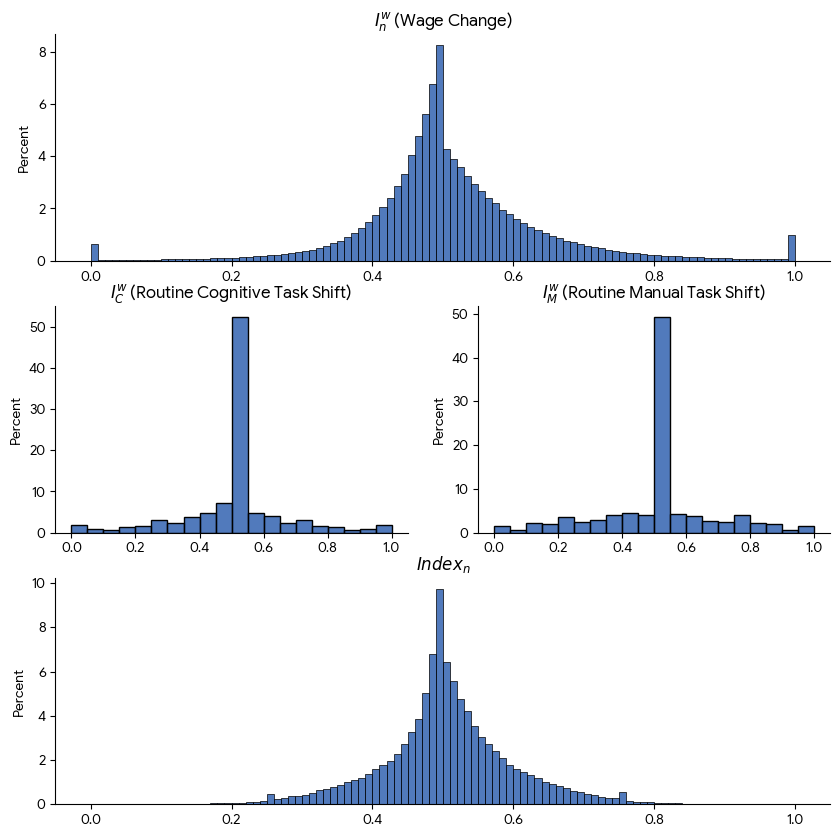

In [89]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(3, 2)

color = color_palette['blue']

ax1 = fig.add_subplot(gs[0, :])
sns.histplot(df["wages_mean_diff_normalized"], stat="percent", binwidth=0.01, color=color, ax=ax1)
ax1.set_title("$I_n^w$ (Wage Change)")

# Two subplots in the bottom row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(df["diff_r_cog_subsector_normalized"], stat="percent", binwidth=0.05, color=color, ax=ax2)
sns.histplot(df["diff_r_man_subsector_normalized"], stat="percent", binwidth=0.05, color=color, ax=ax3)
ax2.set_title("$I_C^w$ (Routine Cognitive Task Shift)")
ax3.set_title("$I_M^w$ (Routine Manual Task Shift)")


ax4 = fig.add_subplot(gs[2, :])
sns.histplot(df["index_subsector"], stat="percent", binwidth=0.01, color=color, ax=ax4)
ax4.set_title("$Index_n$")

sns.despine()

fig.savefig("image-2.png", dpi=300, bbox_inches="tight")

In [90]:
group_cols = [
    "workforce_board_code",
    "employment_status",
    "program_year",
    "occupational_code_pre",
    "received_training",
    "funding_stream",
    "training_service_1",
    "age",
    "state",
    "race",
    "low_income_status",
    "highest_educational_level",
    "r_cog_pre",
    "r_man_pre",
    "sex"
]

group_cols_map = {feature: feature_name_mapping[feature] for feature in group_cols}

summary_tables = []

for col in group_cols:
    # compute mean per groupcol, then describe the mean values
    desc = (
        df
        .group_by(col)
        .agg((pl.col("index_subsector") > 0.5).mean().alias(f"{col}_mean"))
        .select(f"{col}_mean")
        .describe()
        .rename({f"{col}_mean": col})
    )
    summary_tables.append(desc)

# merge all describe tables horizontally on "statistic"
summary_statistics = df["index_subsector"].describe().rename({"value": "Participation Period"})
for t in summary_tables:
    summary_statistics = summary_statistics.join(t, on="statistic", how="inner")

summary_statistics = (
    summary_statistics
    .rename(group_cols_map)
    .remove(pl.col("statistic") == "null_count")
)

summary_statistics = summary_statistics.transpose(include_header=True, header_name="feature", column_names="statistic")


In [62]:
print(summary_statistics.to_pandas().to_latex(index=False, escape=True, float_format="%.2f"))

\begin{tabular}{lrrrrrrrr}
\toprule
feature & count & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
Participation Period & 1138736.00 & 0.51 & 0.09 & 0.00 & 0.46 & 0.50 & 0.55 & 1.00 \\
Local Workforce Board (WDB) & 642.00 & 0.51 & 0.10 & 0.00 & 0.47 & 0.50 & 0.54 & 1.00 \\
Employment Status at Entry & 4.00 & 0.51 & 0.04 & 0.48 & 0.49 & 0.49 & 0.49 & 0.57 \\
Program Year & 8.00 & 0.50 & 0.05 & 0.43 & 0.48 & 0.50 & 0.50 & 0.59 \\
Pre-Program Occupation & 1254.00 & 0.47 & 0.20 & 0.00 & 0.41 & 0.48 & 0.54 & 1.00 \\
Received Training Indicator & 2.00 & 0.57 & 0.11 & 0.49 & 0.49 & 0.64 & 0.64 & 0.64 \\
Funding Stream & 5.00 & 0.53 & 0.07 & 0.46 & 0.48 & 0.49 & 0.58 & 0.64 \\
Training Service Type & 14.00 & 0.61 & 0.09 & 0.45 & 0.49 & 0.63 & 0.68 & 0.75 \\
Participant Age & 87.00 & 0.47 & 0.09 & 0.26 & 0.39 & 0.48 & 0.52 & 0.75 \\
State & 52.00 & 0.50 & 0.04 & 0.35 & 0.48 & 0.50 & 0.52 & 0.64 \\
Race / Ethnicity & 8.00 & 0.50 & 0.02 & 0.47 & 0.50 & 0.51 & 0.51 & 0.54 \\
Low Income 

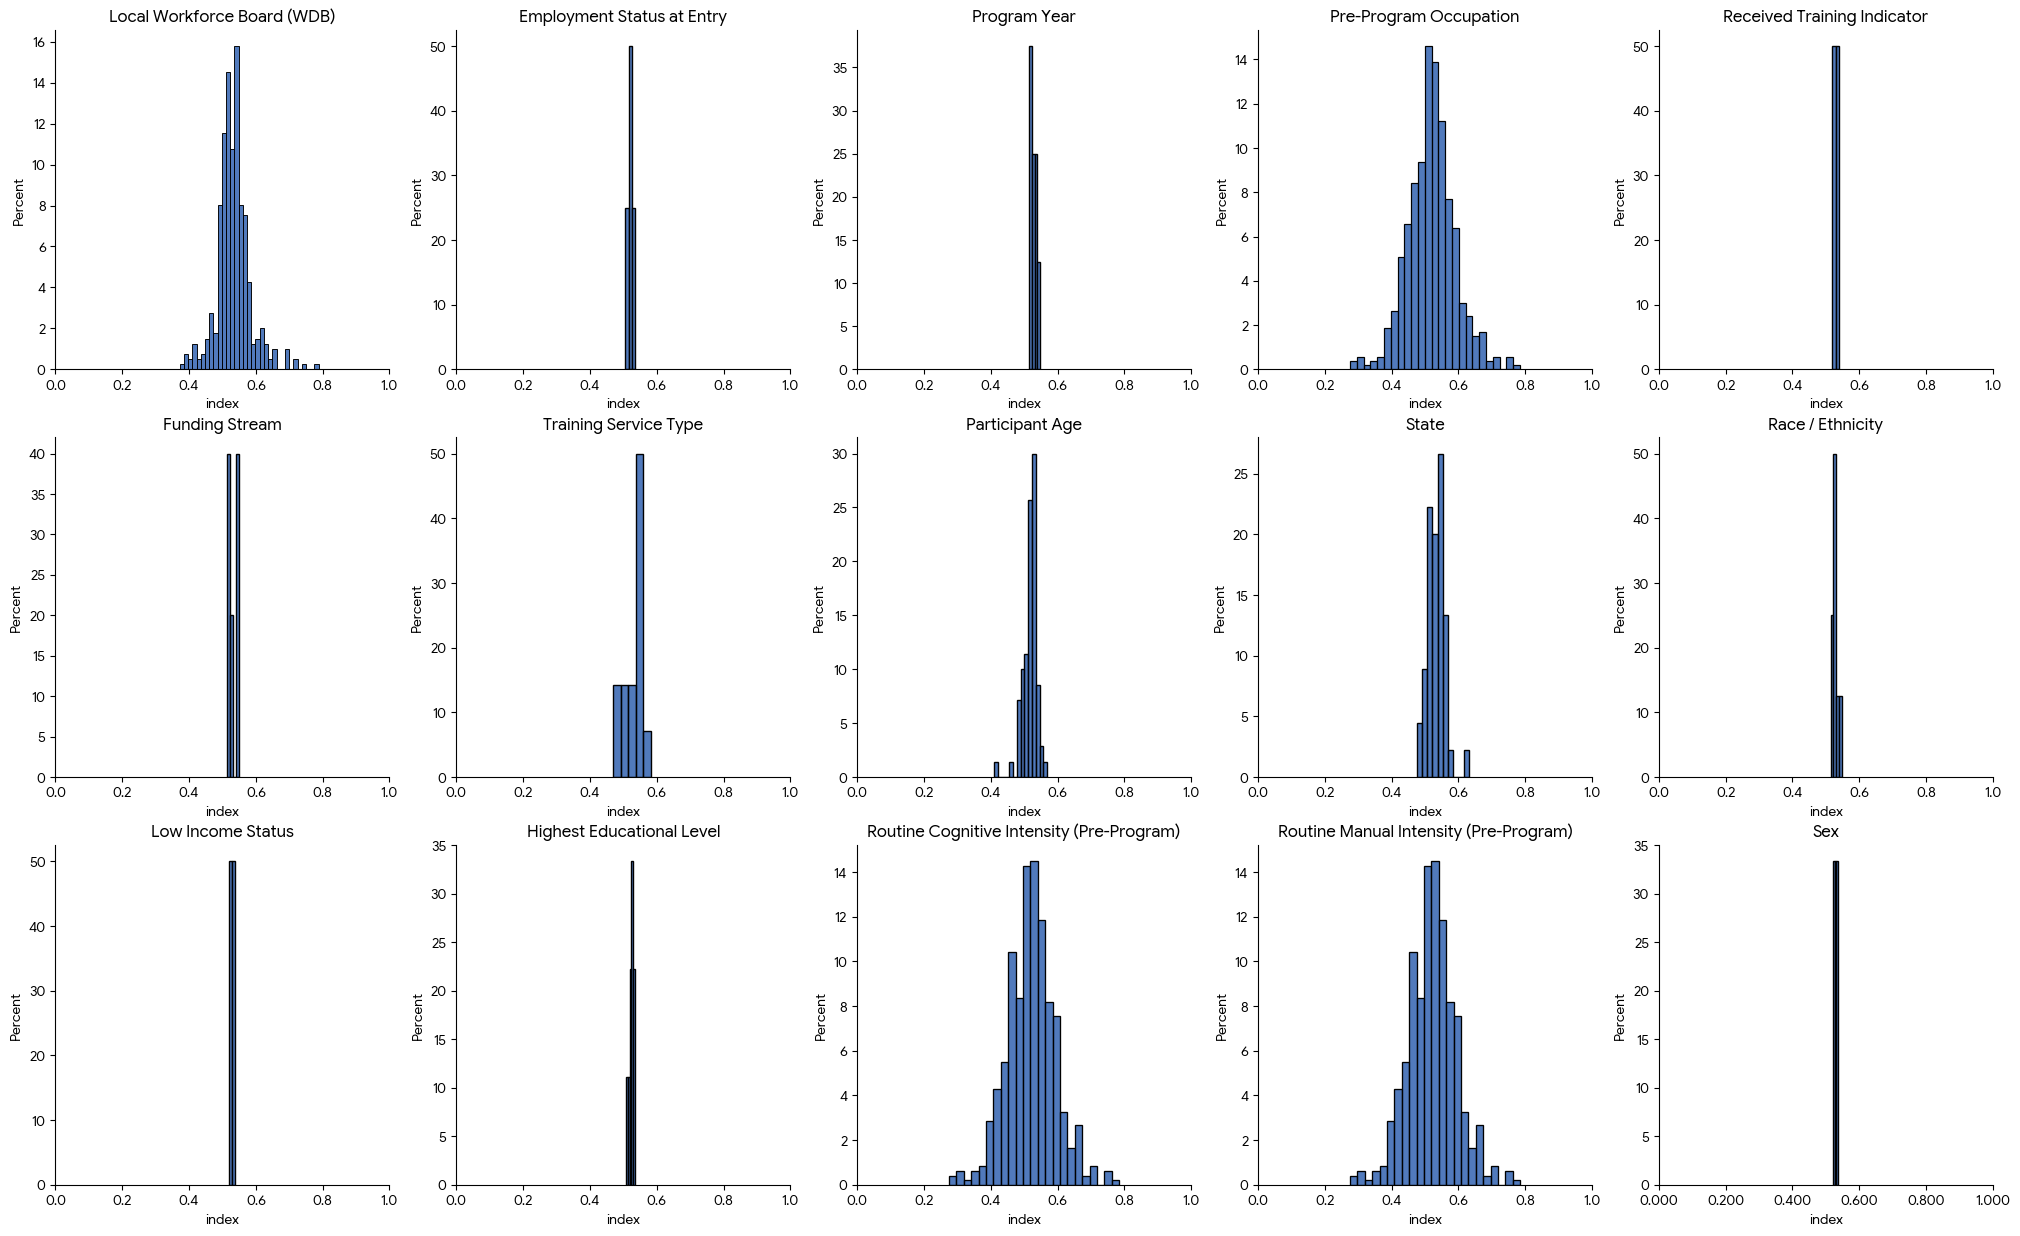

In [97]:
n_cols = 5
n_rows = math.ceil(len(group_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))

color = color_palette['blue']

axes = axes.flatten()

df_plot = df.rename(group_cols_map)

for i, col in enumerate(group_cols_map.values()):
  ax = axes[i]
  sns.histplot(df_plot.group_by(col).agg(pl.col("index").mean()), x="index", stat="percent", color=color, ax=ax)

  ax.set_title(col)
  ax.set_xlim(0, 1)

plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

sns.despine()

fig.savefig("image-3.png", dpi=300, bbox_inches="tight")


### Index Robustness & Sensitivity

[['workforce_board_code'],
 ['employment_status'],
 ['program_year'],
 ['occupational_code_pre'],
 ['received_training'],
 ['funding_stream'],
 ['training_service_1'],
 ['age'],
 ['state'],
 ['race'],
 ['low_income_status'],
 ['highest_educational_level'],
 ['r_cog_pre'],
 ['r_man_pre'],
 ['sex']]

In [143]:
rng = np.random.default_rng(seed=42)

group_cols = [
    "workforce_board_code",
    "employment_status",
    "program_year",
    "occupational_code_pre",
    "received_training",
    "funding_stream",
    "training_service_1",
    "age",
    "state",
    "race",
    "low_income_status",
    "highest_educational_level",
    "r_cog_pre",
    "r_man_pre",
    "sex"
]

groupings = [[group] for group in group_cols]

def random_weights(rng=rng):
    w = rng.random(3)
    return w / w.sum()

N = 500

# Create a container for results per grouping where
# key = tuple of grouping columns,  and
# value = dict with correlations, rank_changes, n_groups
n_groups_baseline = df.select(pl.len()).item()
mc_results = {
    None: {
        "correlations": [],
        "max_pct_rank_shift": [],
        "mean_pct_rank_shift": [],
        "median_pct_rank_shift": [],
        "n_groups": n_groups_baseline,
    }
}

for group_cols in groupings:
    mc_results[tuple(group_cols)] = {
        "correlations": [],
        "max_pct_rank_shift": [],
        "mean_pct_rank_shift": [],
        "median_pct_rank_shift": [],
        "n_groups": df.select(pl.col(group_cols).n_unique()).item(),
    }


# Perform Monte Carlo over weights on the grouped data
for _ in range(N):
  w1, w2, w3 = random_weights()

  df_test = df.with_columns(
      (
          w1 * pl.col("wages_mean_diff_normalized")
        + w2 * (1 - pl.col("diff_r_cog_subsector_normalized"))
        + w3 * (1 - pl.col("diff_r_man_subsector_normalized"))
      ).alias("index_test")
  )

  baseline_ranks = df["index_subsector"].rank("average")
  baseline_pct = baseline_ranks / n_groups_baseline

  # correlation
  corr = df_test.select(
      pl.corr("index_subsector", "index_test", method="spearman")
  ).item()
  mc_results[None]["correlations"].append(corr)

  # rank stability
  test_ranks = df_test["index_test"].rank("average")
  test_pct = test_ranks / n_groups_baseline

  pct_rank_shifts = (baseline_pct - test_pct).abs()
  max_pct_rank_shift = pct_rank_shifts.max()        # worst-case movement
  mean_pct_rank_shift = pct_rank_shifts.mean()      # average movement
  median_pct_rank_shift = pct_rank_shifts.median()  # typical movement

  mc_results[None]["max_pct_rank_shift"].append(max_pct_rank_shift)
  mc_results[None]["mean_pct_rank_shift"].append(mean_pct_rank_shift)
  mc_results[None]["median_pct_rank_shift"].append(median_pct_rank_shift)

  for group_cols in groupings:

    df_group = (
        df_test
        .group_by(group_cols)
        .agg(
            (pl.col("index_subsector") > 0.5).mean().alias("index_subsector"),
            (pl.col("index_test") > 0.5).mean().alias("index_test")
        )
    )

    # Baseline ranks at group level
    n_groups = df_group.height
    baseline_ranks = df_group["index_subsector"].rank("average")
    baseline_pct = baseline_ranks / n_groups


    # Calculate the Spearman correlation between baseline and test index
    corr = df_group.select(
        pl.corr("index_subsector", "index_test", method="spearman")
    ).item()

    mc_results[tuple(group_cols)]["correlations"].append(corr)

    # Calculate the rank stability at the group level
    test_ranks = df_group["index_test"].rank("average")
    test_pct = test_ranks / n_groups

    pct_rank_shifts = (baseline_pct - test_pct).abs()
    max_pct_rank_shift = pct_rank_shifts.max()        # worst-case movement
    mean_pct_rank_shift = pct_rank_shifts.mean()      # average movement
    median_pct_rank_shift = pct_rank_shifts.median()  # typical movement

    mc_results[tuple(group_cols)]["max_pct_rank_shift"].append(max_pct_rank_shift)
    mc_results[tuple(group_cols)]["mean_pct_rank_shift"].append(mean_pct_rank_shift)
    mc_results[tuple(group_cols)]["median_pct_rank_shift"].append(median_pct_rank_shift)


In [150]:
group_cols_map

{'sex': 'Sex'}

In [151]:
group_cols = [
    "workforce_board_code",
    "employment_status",
    "program_year",
    "occupational_code_pre",
    "received_training",
    "funding_stream",
    "training_service_1",
    "age",
    "state",
    "race",
    "low_income_status",
    "highest_educational_level",
    "r_cog_pre",
    "r_man_pre",
    "sex"
]

group_cols_map = {feature: feature_name_mapping[feature] for feature in group_cols}

df_groups = []

for grouping, res in mc_results.items():

  df_group = pl.DataFrame(mc_results[grouping])

  df_group = df_group.select(
    pl.col("n_groups").mean(),
    pl.col("correlations").mean().alias("correlations_mean"),
    pl.col("correlations").min().alias("correlations_min"),
    pl.col("median_pct_rank_shift").mean().alias("median_pct_rank_shift_mean"),
    pl.col("max_pct_rank_shift").mean().alias("max_pct_rank_shift_mean")
)

  df_group = df_group.with_columns(
      pl.lit(grouping[0] if grouping else "participation_period").alias("grouping")
  )

  df_groups.append(df_group)

df_groups = pl.concat(df_groups)["grouping",
                                 "n_groups",
                                 "correlations_mean",
                                 "correlations_min",
                                 "median_pct_rank_shift_mean",
                                 "max_pct_rank_shift_mean"]

df_groups = (
    df_groups
    .with_columns(
        pl.col("grouping").replace_strict(group_cols_map, default="")
    )
)
df_groups

grouping,n_groups,correlations_mean,correlations_min,median_pct_rank_shift_mean,max_pct_rank_shift_mean
str,f64,f64,f64,f64,f64
"""""",1.140155e6,0.895547,0.692199,0.035064,0.73285
"""Local Workforce Board (WDB)""",640.0,0.935531,0.833502,0.031851,0.896131
"""Employment Status at Entry""",4.0,0.784,0.2,0.0915,0.183
"""Program Year""",8.0,0.981667,0.904762,0.006875,0.08025
"""Pre-Program Occupation""",1240.0,0.864439,0.650778,0.029897,0.949002
…,…,…,…,…,…
"""Low Income Status""",2.0,1.0,1.0,0.0,0.0
"""Highest Educational Level""",10.0,0.919394,0.818182,0.0482,0.2616
"""Routine Cognitive Intensity (P…",699.0,0.872045,0.708339,0.041845,0.960073


In [152]:
print(df_groups.to_pandas().to_latex(index=False, escape=True, float_format="%.3f"))

\begin{tabular}{lrrrrr}
\toprule
grouping & n\_groups & correlations\_mean & correlations\_min & median\_pct\_rank\_shift\_mean & max\_pct\_rank\_shift\_mean \\
\midrule
 & 1140155.000 & 0.896 & 0.692 & 0.035 & 0.733 \\
Local Workforce Board (WDB) & 640.000 & 0.936 & 0.834 & 0.032 & 0.896 \\
Employment Status at Entry & 4.000 & 0.784 & 0.200 & 0.091 & 0.183 \\
Program Year & 8.000 & 0.982 & 0.905 & 0.007 & 0.080 \\
Pre-Program Occupation & 1240.000 & 0.864 & 0.651 & 0.030 & 0.949 \\
Received Training Indicator & 2.000 & 1.000 & 1.000 & 0.000 & 0.000 \\
Funding Stream & 5.000 & 0.990 & 0.900 & 0.000 & 0.020 \\
Training Service Type & 14.000 & 0.817 & 0.451 & 0.081 & 0.376 \\
Participant Age & 86.000 & 0.950 & 0.896 & 0.016 & 0.597 \\
State & 52.000 & 0.975 & 0.902 & 0.026 & 0.221 \\
Race / Ethnicity & 8.000 & 0.974 & 0.905 & 0.003 & 0.106 \\
Low Income Status & 2.000 & 1.000 & 1.000 & 0.000 & 0.000 \\
Highest Educational Level & 10.000 & 0.919 & 0.818 & 0.048 & 0.262 \\
Routine Cognitiv

# 9999. Playground

In [ ]:
query = """
  SELECT
    program_year,
    received_training,
    COUNT(unique_id) AS count
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  GROUP BY program_year, received_training
  ORDER BY program_year
;
"""

job = bq_client.query(query)

df = job.to_dataframe()

df = pl.DataFrame(df)

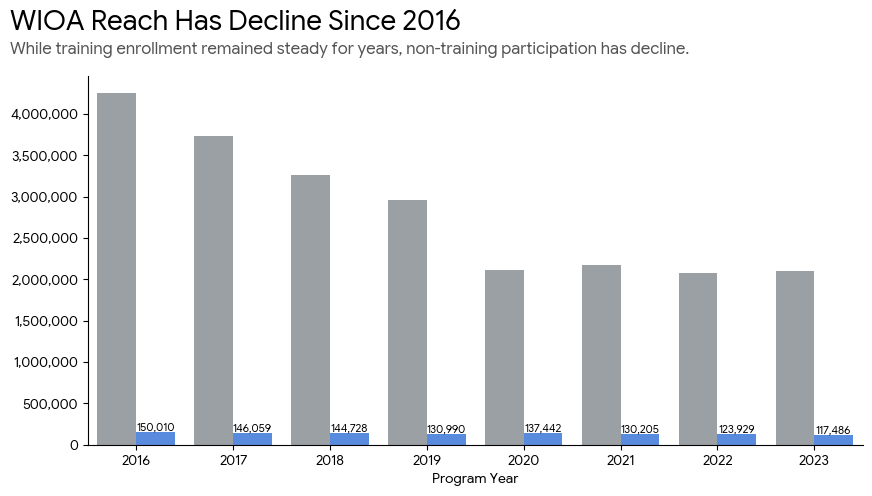

In [ ]:
col = "unique_id"

colors_map = {True: "#4285F4", False: "#9AA0A6"}

labels_map = {
    True: "Received Training",
    False: "No Training"
}

fig = plt.figure(
    figsize=(10, 5),
    FigureClass=TitledFigure,
    title="WIOA Reach Has Decline Since 2016",
    subtitle="While training enrollment remained steady for years, non-training participation has decline.",
)

ax = fig.add_subplot(111)
sns.barplot(df, x="program_year", y="count", hue="received_training", palette=colors_map, ax=ax)

# Get the last x-value to position the text
last_year = df['program_year'].max()

# Iterate through the groups to place labels
for line, name in zip(ax.lines, df['received_training'].unique()):
    # Update the label name
    name = labels_map.get(name, name)

    # Get the last y-value for this specific line
    y_pos = line.get_ydata()[-1]

    # Add text: last_year + small offset, y_position, label name
    ax.text(last_year + 0.1, y_pos, name,
            color=line.get_color(), va='center', fontweight='bold')

# Remove the default legend as it's now redundant
ax.get_legend().remove()


ax.set_xlabel("Program Year")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.bar_label(ax.containers[1], fmt='{:,.0f}', fontsize=8);
# IMPORTANT: finalize after axes exist
fig.finalize_layout()
sns.despine()

plt.show()


In [ ]:
query = """
  SELECT DISTINCT
    program_year,
    received_training,
    PERCENTILE_DISC(wages_mean_pre, 0.5) OVER(
      PARTITION BY program_year, received_training
    ) AS median
  FROM `retraining-index.fact.performance_records`
  WHERE program_year < 2024
  ORDER BY program_year
;
"""

job = bq_client.query(query)

df = job.to_dataframe()

df = pl.DataFrame(df)

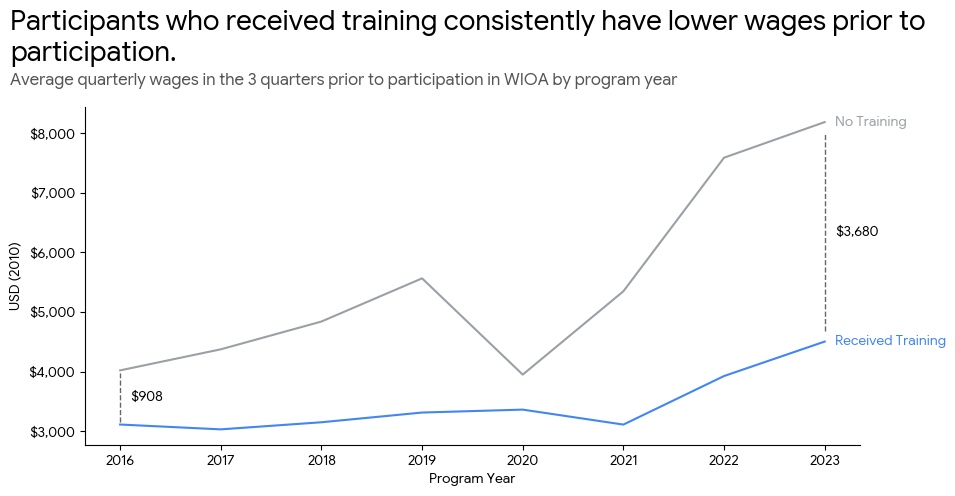

In [ ]:
col = "wages_mean_post"

# df = df_index.group_by(["program_year", "received_training"]).agg(
#   pl.col(col).median().alias("median"),
#   pl.col(col).quantile(0.1).alias("q10"),
#   pl.col(col).quantile(0.9).alias("q90")
# )

colors_map = {True: "#4285F4", False: "#9AA0A6"}

labels_map = {
    True: "Received Training",
    False: "No Training"
}

fig = plt.figure(
    figsize=(10, 5),
    FigureClass=TitledFigure,
    title="Participants who received training consistently have lower wages prior to participation.",
    subtitle="Average quarterly wages in the 3 quarters prior to participation in WIOA by program year",
)

# 1. Setup Data for Annotations
# Assuming df is sorted by year; get the first and last years
start_year = df['program_year'].min()
end_year = df['program_year'].max()

def add_diff_annotation(ax, year, x_offset=0):
    # Find the y-values for both groups at this specific year
    y_vals = df.filter(pl.col("program_year") == year)["median"]
    y_trained = y_vals[1]
    y_control = y_vals[0]
    diff = y_trained - y_control
    if diff > 0:
      ymin = y_control
      ymax = y_trained
    else:
      ymin = y_trained
      ymax = y_control

    y_offset = np.abs(diff) * 0.05

    # Draw a vertical dashed line between the two points
    ax.vlines(x=year + x_offset, ymin=ymin + y_offset, ymax=ymax - y_offset,
              color='black', linestyle='--', linewidth=1, alpha=0.6)

    # Add the text label (the difference)
    # Formatted as +$X,XXX
    ax.text(year + x_offset + 0.1, (y_trained + y_control) / 2,
            f'${np.abs(diff):,.0f}',
            va='center', fontweight='bold', fontsize=10)

ax = fig.add_subplot(111)
sns.lineplot(df, x="program_year", y="median", hue="received_training", palette=colors_map, ax=ax)

# Get the last x-value to position the text
last_year = df['program_year'].max()

# Iterate through the groups to place labels
for line, name in zip(ax.lines, df['received_training'].unique()):
    # Update the label name
    name = labels_map.get(name, name)

    # Get the last y-value for this specific line
    y_pos = line.get_ydata()[-1]

    # Add text: last_year + small offset, y_position, label name
    ax.text(last_year + 0.1, y_pos, name,
            color=line.get_color(), va='center', fontweight='bold')

# Remove the default legend as it's now redundant
ax.get_legend().remove()

# 3. Add the annotations at start and end
add_diff_annotation(ax, start_year, x_offset=-0) # Shift left slightly
add_diff_annotation(ax, end_year, x_offset=0)    # Shift right slightly

ax.set_xlabel("Program Year")
ax.set_ylabel("USD (2010)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
# IMPORTANT: finalize after axes exist
fig.finalize_layout()
sns.despine()

plt.show()


In [ ]:
query = """
  SELECT
    wages_mean_pre,
    wages_mean_post,
    wages_mean_diff,
    received_training
  FROM `retraining-index.fact.performance_records`
  TABLESAMPLE SYSTEM (1 PERCENT)
  WHERE program_year < 2024
;
"""

job = bq_client.query(query)

df = job.to_dataframe()

df = pl.DataFrame(df)

In [ ]:
epsilon = 0.001
df = df.filter(
    (pl.col("wages_mean_pre") > 0) &
    (pl.col("wages_mean_post") > 0)
).with_columns(
    (pl.col("wages_mean_pre") + epsilon).log10().alias("wages_mean_pre_log"),
    (pl.col("wages_mean_post") + epsilon).log10().alias("wages_mean_post_log")
).with_columns(
    (pl.col("wages_mean_post_log") - pl.col("wages_mean_pre_log")).alias("wages_mean_diff_log")
)

In [ ]:
df = df.filter(
    ~pl.col("wages_mean_pre_log").is_null() &
    ~pl.col("wages_mean_post_log").is_null(),
)

In [ ]:
from sklearn.linear_model import LinearRegression

x = df["wages_mean_pre"].to_numpy().reshape(-1, 1)
y = df["wages_mean_post"].to_numpy()


reg = LinearRegression().fit(x, y)

r2 = reg.score(x, y)
a, b = reg.coef_[0], reg.intercept_
x_predict = np.linspace(df["wages_mean_pre"].min(), df["wages_mean_pre"].max())
y_predict = a * x_predict + b
print("R2:", r2)
print("a:", a)
print("b:", b)


df_filtered = df.filter(pl.col("received_training"))

x = df_filtered["wages_mean_pre"].to_numpy().reshape(-1, 1)
y = df_filtered["wages_mean_post"].to_numpy()


reg = LinearRegression().fit(x, y)

r2 = reg.score(x, y)
a, b = reg.coef_[0], reg.intercept_
x_predict_filtered = np.linspace(df["wages_mean_pre"].min(), df["wages_mean_pre"].max())
y_predict_filtered = a * x_predict + b
print("R2:", r2)
print("a:", a)
print("b:", b)


R2: 0.3016064625282894
a: 0.4802347430934181
b: 3461.48221921213
R2: 0.11874284397217116
a: 0.4599658842920601
b: 6151.776092321056


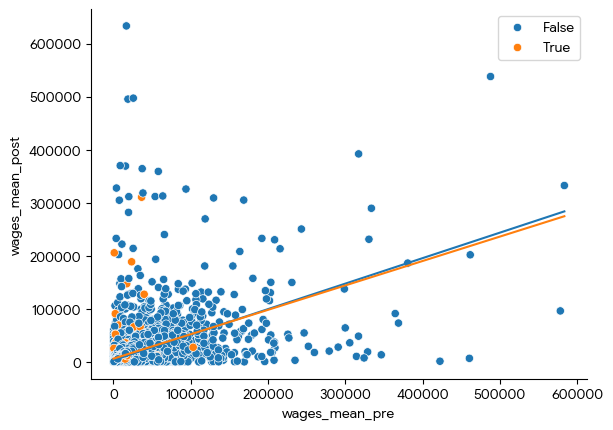

In [ ]:
sns.scatterplot(df, x="wages_mean_pre", y="wages_mean_post", hue="received_training")
sns.lineplot(x=x_predict, y=y_predict)
sns.lineplot(x=x_predict_filtered, y=y_predict_filtered)

sns.despine()

In [ ]:
np.log10(1000)

np.float64(3.0)

In [ ]:
query = """
  SELECT
    wages_mean_pre,
    wages_mean_post,
    wages_mean_diff,
    race
  FROM `retraining-index.fact.performance_records`
  TABLESAMPLE SYSTEM (1 PERCENT)
  WHERE program_year < 2024
;
"""

job = bq_client.query(query)

df = job.to_dataframe()

df = pl.DataFrame(df)

In [ ]:
epsilon = 0.001
df = df.filter(
    (pl.col("wages_mean_pre") > 0) &
    (pl.col("wages_mean_post") > 0)
).with_columns(
    (pl.col("wages_mean_pre") + epsilon).log10().alias("wages_mean_pre_log"),
    (pl.col("wages_mean_post") + epsilon).log10().alias("wages_mean_post_log")
).with_columns(
    (pl.col("wages_mean_post_log") - pl.col("wages_mean_pre_log")).alias("wages_mean_diff_log")
)

In [ ]:
race_map = {
    1: "Hispanic",
    2: "Asian (not Hispanic)",
    3: "Black (not Hispanic)",
    4: "Native Hawaiian or Pacific Islander (not Hispanic)",
    5: "American Indian or Alaska Native (not Hispanic)",
    6: "White (not Hispanic)",
    7: "Multiple Race (not Hispanic)",
}


df = df.with_columns(
    pl.col("race").replace_strict(race_map, default=None)
)

<Axes: xlabel='wages_mean_pre_log', ylabel='Count'>

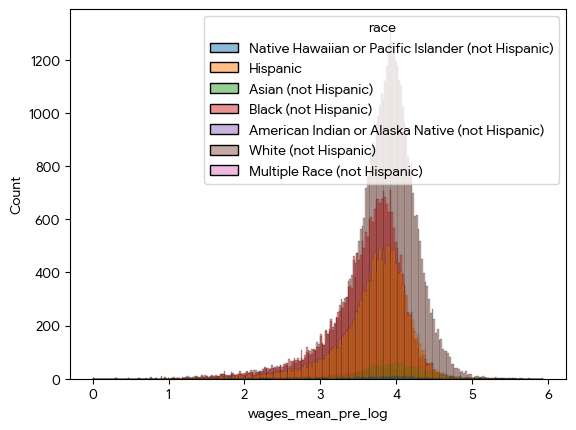

In [ ]:
sns.histplot(df, x="wages_mean_pre_log", hue="race", common_norm=False)